# FR labour-supply data walkthrough — original data, step by step

Read the **original FR microdata**, then clean / filter / price it one inspectable step at a time. You see the dataframe and the household funnel after every step. No engine-ready files, no reproduction oracles.

**What is grounded vs. what you confirm**
- The **eligibility chain** (the cleaning/filtering logic) is transcribed from your DE adapter (`dclaborsupply_app.de.data_prep`), which is a deliberate FR-mirror — so these rules *are* the FR rules.
- The **column names** are the standardized EUROMOD input variables. Cell 1 checks which are actually present in your file, so you verify them — I'm not asserting your schema.
- The **one thing I cannot know** is the path to your FR raw file. It is the single `# CONFIRM (path)` below.
- Places where **FR genuinely differs from DE** are flagged `# FR-SPECIFIC`.

## 0. Read the original FR microdata

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
pd.set_option('display.max_columns', 80); pd.set_option('display.width', 200)

# THE ONE INPUT I CANNOT KNOW. Your FR EU-SILC / EUROMOD-input microdata file.
# EUROMOD input files are tab-separated .txt (same format as the DE_2017_a2.txt the
# DE adapter reads). Fill in the real path; I am deliberately not guessing it.
FR_RAW = Path('C:/Users/hisham/MNL/EUROMOD-STORAGE/Data/FR/FR_2016_a3.txt')   # CONFIRM (path)

raw = pd.read_csv(FR_RAW, sep='\t')   # EUROMOD input is tab-separated
print('raw shape   :', raw.shape)
print('n households:', raw['idhh'].nunique() if 'idhh' in raw else '? (no idhh col)')
print('n persons   :', len(raw))
raw.head()

raw shape   : (26560, 124)
n households: 11459
n persons   : 26560


,idhh,idperson,idfather,idmother,idpartner,idorighh,idorigperson,dag,dmb,dgn,dms,dcz,ddi,drgur,drgmd,drgru,ddt,dwt,dsu00,dsu01,dsu02,dncsy,dcu,dct,dec,decde,deh,dehde,dey,dew,drgn2,drgn1,drg01,les,lcs,lfs,lindi,liwmy,liwftmy,liwptmy,...,bchyc,bchcc,bchot,bsa00,bsaot,pdi00,bdi,bsuwd,bunmt,bunct,yempv,bsaoa,poa00,bhotn,bhoot,yem_hour,yem00,yemxp,amrrm,amrtn,ate,aco,aca,afc,xmp,xpp,xhc,xhcrt,xhcmomi,xhcot,e20ps_o,e20pspo_o,e20psmd_o,e20pslw_o,liwmy_f,lhw_f,liwwh_f,lunmy_f,yem_f,yse_f
0,1483000,148300001,0,0,148300002,1483000,148300001,55,5,1,2,2,0,1,0,0,22016,8113.981,0,147,48,0,1,5,0,-1,5,500,18,1984,1,1,1,2,1,5,6,12,0,12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,72.190476,631.66667,0.00000,3,1,1,1,3,0.0,0.0,0.0,196.50,0.0,161.0,35.50,0,0,0,0,1,1,1,1,1,1
1,1483000,148300002,0,0,148300001,1483000,148300002,41,11,0,2,1,0,1,0,0,22016,8113.981,0,147,48,0,1,5,0,-1,5,500,18,2004,1,1,1,3,1,5,12,12,12,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,68.323810,2391.33330,597.83333,3,1,1,1,3,0.0,0.0,0.0,196.50,0.0,161.0,35.50,0,0,0,0,1,1,1,1,1,1
2,1483000,148300003,148300001,148300002,0,1483000,148300003,7,11,1,1,1,-1,1,0,0,22016,8113.981,0,147,48,0,0,5,2,10,0,0,0,-1,1,1,1,6,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.00000,3,1,1,1,3,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0,0,0,0,3,3,3,3,3,3
3,1483000,148300004,148300001,148300002,0,1483000,148300004,4,8,1,1,1,-1,1,0,0,22016,8113.981,0,147,48,0,0,5,1,0,0,0,0,-1,1,1,1,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.00000,3,1,1,1,3,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0,0,0,0,3,3,3,3,3,3
4,1484400,148440001,0,0,0,1484400,148440001,54,8,0,1,1,0,1,0,0,22016,9235.096,0,147,198,0,0,5,0,-1,3,353,13,1979,1,1,1,3,0,50,2,0,0,0,...,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,318.33333,0.0,0.0,0.0,0.0,0.0,0.0,72.363636,2321.66670,0.00000,6,4,1,1,1,0.0,0.0,0.0,749.33,435.0,0.0,314.33,10,0,1,0,1,1,1,1,1,1


## 1. Inspect the schema (you verify, not me)
Confirms which EUROMOD-standard variables your file actually carries, and which FR-specific ones are present.

In [2]:
print('--- all columns ---'); print(sorted(raw.columns)); print()

core = ['idhh','idperson','idpartner','dag','dgn','dms','dec','ddi','deh',
        'les','lhw','loc','yem','yse','yivwg']
print('core EUROMOD vars present:', [c for c in core if c in raw.columns])
print('core EUROMOD vars MISSING:', [c for c in core if c not in raw.columns])
print()
# FR-SPECIFIC variables to look for (these are where FR differs from the DE file):
fr_specific = ['lma','drgn1','drgur','drgmd','drgru','yem00','yemxp','dwt',
               'byr','pdi','poa','psu','idfather','idmother','idorighh']
for c in fr_specific:
    print(f'  {c:10s}: {"present" if c in raw.columns else "absent"}')

--- all columns ---
['aca', 'aco', 'afc', 'amrrm', 'amrtn', 'ate', 'bch00', 'bchcc', 'bched', 'bchlg', 'bchot', 'bchyc', 'bdi', 'bed', 'bfa', 'bhl', 'bho', 'bhoot', 'bhotn', 'bsa', 'bsa00', 'bsaoa', 'bsaot', 'bsuwd', 'bun', 'bunct', 'bunmt', 'bunmy', 'dag', 'dct', 'dcu', 'dcz', 'ddi', 'ddt', 'dec', 'decde', 'deh', 'dehde', 'dew', 'dey', 'dgn', 'dmb', 'dms', 'dncsy', 'drg01', 'drgmd', 'drgn1', 'drgn2', 'drgru', 'drgur', 'dsu00', 'dsu01', 'dsu02', 'dwt', 'e20ps_o', 'e20pslw_o', 'e20psmd_o', 'e20pspo_o', 'idfather', 'idhh', 'idmother', 'idorighh', 'idorigperson', 'idpartner', 'idperson', 'kfb', 'kfbcc', 'kfbmy', 'kivho', 'lcs', 'les', 'lfs', 'lhw', 'lhw_f', 'lindi', 'liwftmy', 'liwmy', 'liwmy_f', 'liwptmy', 'liwwh', 'liwwh_f', 'loc', 'lowas', 'lpemy', 'lse', 'lunmy', 'lunmy_f', 'pdi', 'pdi00', 'pdimy', 'poa', 'poa00', 'poamy', 'psu', 'psumy', 'tad', 'tis', 'tscer', 'twl', 'xhc', 'xhcmomi', 'xhcot', 'xhcrt', 'xmp', 'xpp', 'yds', 'ydses_o', 'yem', 'yem00', 'yem_f', 'yem_hour', 'yemmy', 'yem

## 2. Eligibility config (FR-mirror constants, from the DE adapter)
These are the frozen FR rule constants the DE adapter mirrors.

In [3]:
CONFIG = dict(
    age_range=(20, 60),
    allowed_les=(3, 5, 7),               # employee / unemployed / inactive deciders
    wage_bounds=(2.0, 170.0),            # employee-decider yivwg bounds
    other_member_income_threshold=50.0,  # |yem|/|yse| above this = earning non-decider
    hours_cap_high=70, hours_floor_low=10, hours_inactive_threshold=5,
    retire_cols=('byr', 'pdi', 'poa', 'psu'),   # CONFIRM FR benefit-receipt columns
)
CONFIG

{'age_range': (20, 60),
 'allowed_les': (3, 5, 7),
 'wage_bounds': (2.0, 170.0),
 'other_member_income_threshold': 50.0,
 'hours_cap_high': 70,
 'hours_floor_low': 10,
 'hours_inactive_threshold': 5,
 'retire_cols': ('byr', 'pdi', 'poa', 'psu')}

## 3. Classify households (single / opposite-sex couple)
Single = one adult with no partner link; couple_mf = two mutually-linked opposite-sex adults. `ruro_decider` marks the adults whose labour supply is modelled.

In [4]:
ADULT = CONFIG['age_range'][0]
dag = pd.to_numeric(raw['dag'], errors='coerce').fillna(-1)
idp = pd.to_numeric(raw['idpartner'], errors='coerce').fillna(0).astype('int64')
id2partner = dict(zip(raw['idperson'].astype('int64'), idp))
idset = set(raw['idperson'].astype('int64'))

def _mutual(a, b):
    return b != 0 and b in idset and id2partner.get(b, 0) == a

cls = {}
for hh, g in raw.groupby('idhh'):
    ad = g[pd.to_numeric(g['dag'], errors='coerce') >= ADULT]
    n = len(ad)
    if n == 0:
        cls[hh] = 'excl_no_adult'
    elif n == 1:
        cls[hh] = 'single' if int(ad['idpartner'].iloc[0]) == 0 else 'excl_2adult_no_link'
    elif n == 2:
        a, b = ad['idperson'].astype('int64').tolist()
        if _mutual(a, b) and _mutual(b, a):
            gens = sorted(pd.to_numeric(ad['dgn'], errors='coerce').tolist())
            cls[hh] = 'couple_mf' if gens == [0, 1] else 'excl_same_sex'
        else:
            cls[hh] = 'excl_2adult_no_link'
    else:
        cls[hh] = 'excl_3plus_adults'

raw['household_class'] = raw['idhh'].map(cls)
raw['ruro_decider'] = (raw['household_class'].isin(['single', 'couple_mf'])
                       & (pd.to_numeric(raw['dag'], errors='coerce') >= ADULT)).astype(int)
print(raw.groupby('idhh')['household_class'].first().value_counts())
print('\ndeciders flagged:', int(raw['ruro_decider'].sum()))

household_class
couple_mf              5965
single                 4038
excl_3plus_adults       930
excl_2adult_no_link     452
excl_same_sex            53
excl_no_adult            21
Name: count, dtype: int64

deciders flagged: 15968


## 4. The eligibility chain — one step per cell
Each step prints the household funnel (before -> after) so you watch the sample shrink. A tiny helper logs counts.

In [5]:
def funnel(df, label):
    print(f'{label:48s} households={df["idhh"].nunique():6d}  persons={len(df):6d}')
    return df

def keep_all_deciders(df, cond):
    """Keep a household only if EVERY decider satisfies cond."""
    dec = df['ruro_decider'] == 1
    bad = df.loc[dec & ~cond.reindex(df.index), 'idhh']
    return df[~df['idhh'].isin(pd.unique(bad))].copy()

def drop_hh(df, bad_idhh):
    return df[~df['idhh'].isin(pd.unique(bad_idhh))].copy()

# Step 4.0 — baseline: singles + opposite-sex couples only
work = raw[raw['household_class'].isin(['single', 'couple_mf'])].copy()
funnel(work, '4.0 baseline (single + couple_mf)');

4.0 baseline (single + couple_mf)                households= 10003  persons= 21842


In [6]:
# Step 4.1 — age: every decider in [20, 60]
lo, hi = CONFIG['age_range']
dag = pd.to_numeric(work['dag'], errors='coerce')
work = keep_all_deciders(work, dag.between(lo, hi))
funnel(work, '4.1 age (all deciders 20-60)');

4.1 age (all deciders 20-60)                     households=  5793  persons= 15252


In [7]:
# Step 4.2 — education: every decider dec == 0 (not currently in education)
if 'dec' in work.columns:
    dec = pd.to_numeric(work['dec'], errors='coerce')
    work = keep_all_deciders(work, dec.eq(0))
funnel(work, '4.2 education (deciders dec==0)');

4.2 education (deciders dec==0)                  households=  5557  persons= 14701


In [8]:
# Step 4.3 — retirement/disability: HH sum of (byr+pdi+poa+psu) == 0
# CONFIRM these are the right FR benefit-receipt columns (DE adapter used these four).
rc = [c for c in CONFIG['retire_cols'] if c in work.columns]
print('retire cols used:', rc)
if rc:
    retire = work[rc].apply(pd.to_numeric, errors='coerce').fillna(0.0).sum(axis=1)
    work['_retire'] = retire
    hh_retire = work.groupby('idhh')['_retire'].sum()
    work = drop_hh(work, hh_retire.index[hh_retire > 0]).drop(columns='_retire')
funnel(work, '4.3 retirement/disability (HH sum == 0)');

retire cols used: ['pdi', 'poa', 'psu']
4.3 retirement/disability (HH sum == 0)          households=  4973  persons= 13521


In [9]:
# Step 4.4 — allowed labour status: every decider les in {3, 5, 7}
les = pd.to_numeric(work['les'], errors='coerce')
work = keep_all_deciders(work, les.isin(CONFIG['allowed_les']))
funnel(work, '4.4 allowed LES (deciders in {3,5,7})');

4.4 allowed LES (deciders in {3,5,7})            households=  4010  persons= 10369


In [10]:
# Step 4.5 — other household members: drop HH if any NON-decider is
#   working-age-healthy-not-student  OR  earning (|yem| or |yse| > threshold)
lo, hi = CONFIG['age_range']; thr = CONFIG['other_member_income_threshold']
nondec = work['ruro_decider'] == 0
dag = pd.to_numeric(work['dag'], errors='coerce')
ddi = pd.to_numeric(work.get('ddi', 0), errors='coerce').fillna(0)
dec = pd.to_numeric(work.get('dec', 0), errors='coerce').fillna(0)
yem = pd.to_numeric(work.get('yem', 0.0), errors='coerce').fillna(0.0)
yse = pd.to_numeric(work.get('yse', 0.0), errors='coerce').fillna(0.0)
capable = dag.between(lo, hi) & ddi.eq(0) & dec.eq(0)
earning = (yem > thr) | (yse.abs() > thr)
work = drop_hh(work, work.loc[nondec & (capable | earning), 'idhh'])
funnel(work, '4.5 other members (no capable/earning non-deciders)');

4.5 other members (no capable/earning non-deciders) households=  3887  persons=  9922


In [11]:
# Step 4.6 — hours cap + inactive transition + wage bounds (employee deciders, les==3)
cap, floor, inact = CONFIG['hours_cap_high'], CONFIG['hours_floor_low'], CONFIG['hours_inactive_threshold']
wlo, whi = CONFIG['wage_bounds']
dec_mask = work['ruro_decider'] == 1
les = pd.to_numeric(work['les'], errors='coerce')
lhw = pd.to_numeric(work['lhw'], errors='coerce').fillna(0.0)
emp = dec_mask & les.eq(3)

n_capped = int((emp & (lhw > cap)).sum())
work.loc[emp & (lhw > cap), 'lhw'] = cap                              # cap >70 to 70
lhw = pd.to_numeric(work['lhw'], errors='coerce').fillna(0.0)
work.loc[emp & (lhw > inact) & (lhw <= floor), 'lhw'] = floor         # raise (5,10] to 10
lhw = pd.to_numeric(work['lhw'], errors='coerce').fillna(0.0)

very_low = emp & (lhw <= inact)                                        # <=5h employees
become_inactive = very_low & les.isin(CONFIG['allowed_les'])
n_inactive = int(become_inactive.sum())
work.loc[become_inactive, 'lhw'] = 0
work.loc[become_inactive, 'les'] = 7
for c in ('yem', 'yse', 'yemse'):
    if c in work.columns:
        work.loc[become_inactive, c] = 0.0
work = drop_hh(work, work.loc[very_low & ~les.isin(CONFIG['allowed_les']), 'idhh'])

# Non-employment labour-status rows must have zero observed hours.
les = pd.to_numeric(work['les'], errors='coerce')
lhw = pd.to_numeric(work['lhw'], errors='coerce').fillna(0.0)
nonemp_hours = dec_mask & les.isin([5, 7]) & (lhw > 0)
n_nonemp_hours_zeroed = int(nonemp_hours.sum())
work.loc[nonemp_hours, 'lhw'] = 0

if 'yivwg' in work.columns:                                            # wage bounds on employees
    dec_mask = work['ruro_decider'] == 1; les = pd.to_numeric(work['les'], errors='coerce')
    yivwg = pd.to_numeric(work['yivwg'], errors='coerce')
    bad_wage = dec_mask & les.eq(3) & yivwg.notna() & ((yivwg < wlo) | (yivwg > whi))
    work = drop_hh(work, work.loc[bad_wage, 'idhh'])

print(f'capped >70h: {n_capped}   ->inactive (<=5h): {n_inactive}   nonemp hours->0: {n_nonemp_hours_zeroed}')
work = work.reset_index(drop=True)
funnel(work, '4.6 hours cap + wage bounds (employees)');

capped >70h: 25   ->inactive (<=5h): 6   nonemp hours->0: 407
4.6 hours cap + wage bounds (employees)          households=  3830  persons=  9740


In [12]:
# The surviving analytical sample, split by household type
singles = work[work['household_class'] == 'single'].reset_index(drop=True)
couples = work[work['household_class'] == 'couple_mf'].reset_index(drop=True)
print('singles households:', singles['idhh'].nunique())
print('couples households:', couples['idhh'].nunique())
work.head()

singles households: 1555
couples households: 2275


,idhh,idperson,idfather,idmother,idpartner,idorighh,idorigperson,dag,dmb,dgn,dms,dcz,ddi,drgur,drgmd,drgru,ddt,dwt,dsu00,dsu01,dsu02,dncsy,dcu,dct,dec,decde,deh,dehde,dey,dew,drgn2,drgn1,drg01,les,lcs,lfs,lindi,liwmy,liwftmy,liwptmy,...,bchot,bsa00,bsaot,pdi00,bdi,bsuwd,bunmt,bunct,yempv,bsaoa,poa00,bhotn,bhoot,yem_hour,yem00,yemxp,amrrm,amrtn,ate,aco,aca,afc,xmp,xpp,xhc,xhcrt,xhcmomi,xhcot,e20ps_o,e20pspo_o,e20psmd_o,e20pslw_o,liwmy_f,lhw_f,liwwh_f,lunmy_f,yem_f,yse_f,household_class,ruro_decider
0,1485200,148520001,0,0,148520002,1485200,148520001,31,11,1,1,1,0,0,0,1,22016,6520.411,0,579,0,0,1,5,0,-1,5,500,18,2003,3,2,3,3,0,50,4,12,12,0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,75.754885,2651.4210,1613.57900,3,1,1,1,1,359.71223,0.0,0.0,395.585,0.0,294.62500,100.960000,0,0,0,0,1,1,1,1,1,1,couple_mf,1
1,1485200,148520002,0,0,148520001,1485200,148520002,33,8,0,1,1,0,0,0,1,22016,6520.411,0,579,0,0,1,5,0,-1,5,500,18,2003,3,2,3,3,0,50,8,12,0,12,...,505.81333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.833333,1744.1667,249.16667,3,1,1,1,1,359.71223,0.0,0.0,395.585,0.0,294.62500,100.960000,0,0,0,0,1,1,1,1,1,1,couple_mf,1
2,1485200,148520003,148520001,148520002,0,1485200,148520003,3,5,1,1,1,-1,0,0,1,22016,6520.411,0,579,0,0,0,5,1,0,0,0,0,-1,3,2,3,0,0,0,0,0,0,0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0000,0.00000,3,1,1,1,1,0.00000,0.0,0.0,0.000,0.0,0.00000,0.000000,0,0,0,0,3,3,3,3,3,3,couple_mf,0
3,1485200,148520004,148520001,148520002,0,1485200,148520004,1,5,0,1,1,-1,0,0,1,22016,6520.411,0,579,0,0,0,5,1,0,0,0,0,-1,3,2,3,0,0,0,0,0,0,0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0000,0.00000,3,1,1,1,1,0.00000,0.0,0.0,0.000,0.0,0.00000,0.000000,0,0,0,0,3,3,3,3,3,3,couple_mf,0
4,1487600,148760001,0,0,148760002,1487600,148760001,37,2,1,2,1,0,1,0,0,22016,6902.881,0,147,455,0,1,5,0,-1,5,500,18,2001,1,1,1,3,0,5,7,12,12,0,...,362.83333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.732390,4120.6335,2507.69980,5,1,1,1,1,101438.85000,0.0,0.0,205.665,0.0,163.79167,41.873333,0,0,0,0,1,1,1,1,1,1,couple_mf,1


## 5. Build features (worker flag, hours bands, education, wages)

This cell converts the cleaned EUROMOD person rows into the model-side state variables used by the French RURO/MNL pipeline. The important French-specific point is the worker definition: `scripts/enhanced/enh_RURO_prep.py::_compute_is_worker` uses `lma == 1 and lhw > 0` when `lma` is informative, and only falls back to `les == 3 and lhw > 0` when `lma` is absent or degenerate. That choice matters downstream because occupation (`loc_ruro`/`loc4`) is only defined for workers; non-workers must get the `-1` occupation sentinel.

In [13]:
df = work.copy()
lhw = pd.to_numeric(df['lhw'], errors='coerce').fillna(0.0)
les = pd.to_numeric(df['les'], errors='coerce')

# FR-SPECIFIC worker flag: mirror scripts/enhanced/enh_RURO_prep.py::_compute_is_worker.
if 'lma' in df.columns:
    lma = pd.to_numeric(df['lma'], errors='coerce').fillna(0)
    use_lma = bool((lma == 1).any() and lma.nunique(dropna=True) > 1)
else:
    lma = None
    use_lma = False

if use_lma:
    df['is_worker'] = ((lma == 1) & (lhw > 0)).astype('int8')
    print('worker rule: lma==1 & lhw>0 (French MNL hierarchy)')
else:
    df['is_worker'] = (les.eq(3) & (lhw > 0)).astype('int8')
    print('worker rule: les==3 & lhw>0 fallback')
df['working'] = (lhw > 0).astype('int8')

# hours bands (certified RURO definitions, identical to DE)
df['working_pt1'] = ((lhw >= 18.5) & (lhw <= 20.5)).astype('int8')
df['working_pt2'] = ((lhw >= 29.5) & (lhw <= 30.5)).astype('int8')
df['working_ft']  = ((lhw >= 37.5) & (lhw <= 40.5)).astype('int8')
df['working_lh']  = ((df['working'] == 1) & (lhw >= 44.5) & (lhw <= 70.0)).astype('int8')

# education (EUROMOD deh): low {0,1,2}, mid {3,4}, high {5}
deh = pd.to_numeric(df['deh'], errors='coerce')
df['educL'] = deh.isin([0, 1, 2]).astype('int8')
df['educM'] = deh.isin([3, 4]).astype('int8')
df['educH'] = deh.eq(5).astype('int8')

# wages: realised wage 0 for non-workers; offer wage kept for everyone
yivwg = pd.to_numeric(df['yivwg'], errors='coerce').fillna(0.0)
df['wage_for_draws'] = yivwg
df['wage_ruro'] = np.where(df['is_worker'].to_numpy() == 1, yivwg.to_numpy(), 0.0)

# age_norm centred on the decider sample mean
dagn = pd.to_numeric(df['dag'], errors='coerce')
mean_age = float(dagn[df['ruro_decider'] == 1].mean())
df['age_norm'] = dagn - mean_age
df['age_norm2'] = df['age_norm'] ** 2
df['female'] = (pd.to_numeric(df['dgn'], errors='coerce') == 0).astype('int8')

# FR-SPECIFIC (region): unlike DE (constant 0, dropped), FR drgn1/drgur/drgmd/drgru VARY -> KEEP.
for c in ['drgn1', 'drgur', 'drgmd', 'drgru']:
    print(f'  region {c}: {"present (keep for FR)" if c in df.columns else "absent"}')
# FR-SPECIFIC (earnings): FR splits employment income into yem00 / yemxp (35h overtime).
#   DE used a single yem. Relevant when you mutate earnings for pricing alternatives.
print('  yem00/yemxp present:', ('yem00' in df.columns, 'yemxp' in df.columns))

df[['idhh','dag','dgn','les','lhw','is_worker','working_ft','working_lh','educL','educM','educH','wage_ruro']].head(10)

worker rule: les==3 & lhw>0 fallback
  region drgn1: present (keep for FR)
  region drgur: present (keep for FR)
  region drgmd: present (keep for FR)
  region drgru: present (keep for FR)
  yem00/yemxp present: (True, True)


,idhh,dag,dgn,les,lhw,is_worker,working_ft,working_lh,educL,educM,educH,wage_ruro
0,1485200,31,1,3,50,1,0,1,0,0,1,19.684615
1,1485200,33,0,3,39,1,1,0,0,0,1,11.794872
2,1485200,3,1,0,0,0,0,0,1,0,0,0.000000
3,1485200,1,0,0,0,0,0,0,1,0,0,0.000000
4,1487600,37,1,3,50,1,0,1,0,0,1,30.592308
5,1487600,32,0,3,45,1,0,1,0,0,1,26.645300
6,1487600,1,0,0,0,0,0,0,1,0,0,0.000000
7,1495800,51,0,3,35,1,0,0,1,0,0,11.164835
8,1495800,18,1,6,0,0,0,0,1,0,0,0.000000
9,1495800,11,0,6,0,0,0,0,1,0,0,0.000000


### 5b. Build `loc_ruro` and `loc4`

The French MNL files carry occupation as two model variables. `loc_ruro` is the cleaned one-digit occupation: non-workers are coded `-1`; workers with missing, invalid, or armed-forces occupation are kept as unknown-worker `-2`; valid ISCO major groups remain `1` through `9`. `loc4` then collapses valid worker occupations into the four certified task groups. The important convention from the MNL reports is that observed working rows with `loc4 = -2` are retained; they are unknown observed occupations, not non-work rows. Later simulated working alternatives are imputed/drawn into valid task groups `{1,2,3,4}`.

In [14]:
# Dedicated loc_ruro / loc4 construction (certified task groups)
from dclaborsupply_app.de.data_prep import collapse_loc_to_loc4

if 'loc' not in df.columns:
    raise KeyError("Cannot build loc4: raw occupation column 'loc' is missing.")

if 'loc_raw' not in df.columns:
    df['loc_raw'] = df['loc']

loc_src = pd.to_numeric(df['loc'], errors='coerce').fillna(-2).astype('int16')
isw = pd.to_numeric(df['is_worker'], errors='coerce').fillna(0).astype(int)
df['loc_ruro'] = loc_src
valid_worker_loc = loc_src.isin(list(range(0, 10)))
df.loc[(isw == 1) & ~valid_worker_loc, 'loc_ruro'] = -2
df.loc[isw != 1, 'loc_ruro'] = -1

loc4, loc_armed = collapse_loc_to_loc4(df['loc_ruro'])
df['loc4'] = loc4.astype('int16')
df['loc_armed'] = loc_armed.astype('int8')

model_worker = isw == 1
model_nonworker = ~model_worker
unknown_worker = model_worker & (pd.to_numeric(df['loc4'], errors='coerce') == -2)
bad_worker = model_worker & ~pd.to_numeric(df['loc4'], errors='coerce').isin([-2, 1, 2, 3, 4])
bad_nonworker = model_nonworker & (pd.to_numeric(df['loc4'], errors='coerce') != -1)
assert not bad_worker.any(), f"is_worker rows with unsupported loc4 remain: {int(bad_worker.sum())}"
assert not bad_nonworker.any(), f"non-is_worker rows with loc4 != -1 remain: {int(bad_nonworker.sum())}"
if unknown_worker.any():
    bad_cols = [c for c in ['idhh', 'idperson', 'les', 'lhw', 'is_worker', 'loc', 'loc_ruro', 'loc4', 'loc_armed'] if c in df.columns]
    print(
        f"Observed is_worker rows with loc4=-2: {int(unknown_worker.sum())} "
        f"({df.loc[unknown_worker, 'idhh'].nunique()} households). Keeping them: "
        "MNL convention treats -2 as unknown observed occupation; simulated working draws are mode-imputed to {1,2,3,4}."
    )
    display(df.loc[unknown_worker, bad_cols].head(20))

print('loc4 counts:')
display(df['loc4'].value_counts(dropna=False).sort_index())
df[['idhh', 'idperson', 'les', 'lhw', 'is_worker', 'loc', 'loc_ruro', 'loc4', 'loc_armed']].head(10)

Observed is_worker rows with loc4=-2: 37 (35 households). Keeping them: MNL convention treats -2 as unknown observed occupation; simulated working draws are mode-imputed to {1,2,3,4}.


,idhh,idperson,les,lhw,is_worker,loc,loc_ruro,loc4,loc_armed
111,1549100,154910002,3,60,1,0,0,-2,1
649,1783400,178340001,3,39,1,0,0,-2,1
681,1803200,180320001,3,55,1,0,0,-2,1
718,1825600,182560001,3,50,1,0,0,-2,1
738,1831000,183100001,3,50,1,0,0,-2,1
1298,2085000,208500001,3,50,1,0,0,-2,1
1787,2302100,230210001,3,60,1,0,0,-2,1
2014,2401800,240180002,3,48,1,0,0,-2,1
2102,2452300,245230002,3,48,1,0,0,-2,1
2130,2463900,246390001,3,50,1,0,0,-2,1


loc4 counts:


loc4
-2      37
-1    4221
 1    1457
 2     777
 3     544
 4    2704
Name: count, dtype: int64

,idhh,idperson,les,lhw,is_worker,loc,loc_ruro,loc4,loc_armed
0,1485200,148520001,3,50,1,1,1,4,0
1,1485200,148520002,3,39,1,3,3,4,0
2,1485200,148520003,0,0,0,-1,-1,-1,0
3,1485200,148520004,0,0,0,-1,-1,-1,0
4,1487600,148760001,3,50,1,2,2,4,0
5,1487600,148760002,3,45,1,2,2,4,0
6,1487600,148760003,0,0,0,-1,-1,-1,0
7,1495800,149580001,3,35,1,9,9,1,0
8,1495800,149580002,6,0,0,-1,-1,-1,0
9,1495800,149580003,6,0,0,-1,-1,-1,0


## 6. Price the observed state through EUROMOD (real connector)

This section prices the cleaned observed sample, not simulated alternatives. EUROMOD should receive the cleaned EUROMOD input schema (`idhh`, `idperson`, `lhw`, `yem`, taxes/benefits inputs, etc.), while model-side helper columns such as `is_worker`, `loc_ruro`, `loc4`, and `age_norm` are kept in `df` for later assembly but excluded from the EUROMOD input frame. If this section fails, section 7 cannot run because `priced` will not exist.

In [15]:
from dclaborsupply_app.euromod import EuromodConnector
MODEL_ROOT = Path(r'C:\\Users\\hisham\\MNL\\EUROMOD-STORAGE\\Euromod_model\\EUROMOD_RELEASES_J2.0+')   # CONFIRM (path) what em.Model() loadsds
FR_COUNTRY, FR_SYSTEM, FR_DATASET = 'FR', 'FR_2015', 'FR_2016_a3'    # CONFIRM system/dataset names


In [16]:

if 'df' not in globals():
    raise RuntimeError('Run sections 0-5 first; df is not defined.')
if 'loc4' not in df.columns:
    raise RuntimeError('Run section 5b first; loc4 has not been constructed.')

# Feed EUROMOD the cleaned raw input variables, not model-side derived/control cols.
derived = {'household_class','ruro_decider','is_worker','working','working_pt1','working_pt2',
           'working_ft','working_lh','educL','educM','educH','wage_for_draws','wage_ruro',
           'age_norm','age_norm2','female','loc_raw','loc_ruro','loc4','loc_armed'}
em_input = df[[c for c in df.columns if c not in derived]].copy()
print('EUROMOD input columns:', em_input.shape[1])

conn = EuromodConnector(str(MODEL_ROOT))
res = conn.run(em_input, country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET)
priced = res.output
print('priced shape:', priced.shape, ' (full output)')
print('ils_dispy present:', 'ils_dispy' in priced.columns)
if 'ils_dispy' not in priced.columns:
    raise KeyError("EUROMOD output does not contain 'ils_dispy'. Check FR system/dataset selection.")
if res.warnings:
    print('warnings:', res.warnings[:3])

EUROMOD input columns: 124
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
priced shape: (9740, 388)  (full output)
ils_dispy present: True


## 7. Inspect disposable income (`ils_dispy`)

`ils_dispy` is the disposable-income output used later as the consumption basis. This inspection is deliberately after EUROMOD pricing: it checks that section 6 produced `priced`, that the disposable-income column exists, and that the distribution is finite enough to be usable before any alternatives are generated.

count     9740.000000
mean      1294.911770
std       1340.710089
min       -990.112084
25%          0.000000
50%       1350.907596
75%       2048.788877
max      14169.692181
Name: ils_dispy, dtype: float64


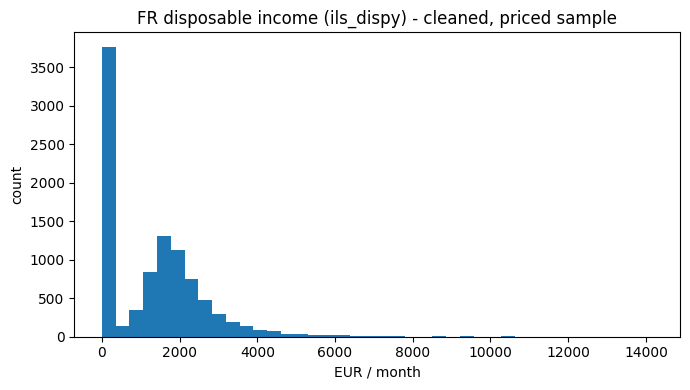

In [17]:
import matplotlib.pyplot as plt
if 'priced' not in globals():
    raise RuntimeError('Run section 6 first; priced is not defined because EUROMOD pricing has not completed.')
if 'ils_dispy' not in priced.columns:
    raise KeyError("priced is missing 'ils_dispy'; check the EUROMOD output in section 6.")
c = pd.to_numeric(priced['ils_dispy'], errors='coerce')
if c.notna().sum() == 0:
    raise ValueError("priced['ils_dispy'] has no numeric values.")
print(c.describe())
plt.figure(figsize=(7, 4))
plt.hist(c.clip(lower=0), bins=40)
plt.title('FR disposable income (ils_dispy) - cleaned, priced sample')
plt.xlabel('EUR / month'); plt.ylabel('count'); plt.tight_layout(); plt.show()

---
## What you have after this
A clean line from your **original FR microdata** to a priced, inspectable sample, with the household funnel visible at every eligibility step. The only path I could not supply is your raw file (cell 0); the eligibility rules are your DE adapter's FR-mirror chain, the column names are EUROMOD-standard and checked in cell 1, and the FR-vs-DE differences (`is_worker`+lma, region kept, yem00/yemxp) are flagged where they bite.

**Next** (only if useful): build the latent-job alternatives from this cleaned sample (`generate_draws_long`) and price them — that step needs an FR earnings-mutation policy mirroring DE's `de_earnings_policy` (the yem00/yemxp 35h split), the one FR piece not yet written.

In [18]:
# ── 8. Restrict to singles (the trial scope) ──────────────────────────────
singles_df = df[df['household_class'] == 'single'].reset_index(drop=True)
print('singles households:', singles_df['idhh'].nunique(), '| persons:', len(singles_df))

# the modelled individuals = the single deciders (one per single household)
singles_dec = singles_df[singles_df['ruro_decider'] == 1].reset_index(drop=True)
print('single deciders   :', len(singles_dec),
      '| female share   :', round(singles_dec['female'].mean(), 3))

singles_dec[['idhh','dag','dgn','female','les','lhw','is_worker',
             'wage_ruro','educL','educM','educH']].head(10)

singles households: 1555 | persons: 2236
single deciders   : 1555 | female share   : 0.541


,idhh,dag,dgn,female,les,lhw,is_worker,wage_ruro,educL,educM,educH
0,1495800,51,0,1,3,35,1,11.164835,1,0,0
1,1496401,40,0,1,3,45,1,14.636753,0,0,1
2,1502500,47,0,1,3,50,1,2.238462,1,0,0
3,1504300,38,1,0,3,55,1,25.919580,0,0,1
4,1516900,37,0,1,3,35,1,23.769231,0,0,1
5,1526601,27,1,0,3,40,1,18.365384,0,0,1
6,1527000,28,1,0,3,35,1,12.000000,0,0,1
7,1533500,31,1,0,3,45,1,8.970085,0,1,0
8,1535100,43,0,1,3,35,1,22.626374,0,0,1
9,1537301,29,1,0,3,20,1,9.346154,0,0,1


In [19]:
# ── 9. Discover the REAL draws / engine-ready API (no guessing) ────────────
import importlib, inspect, pkgutil
import dclaborsupply, dclaborsupply_app

def show_api(pkg):
    for m in pkgutil.walk_packages(pkg.__path__, pkg.__name__ + '.'):
        if any(k in m.name.lower() for k in
               ['draw', 'alternativ', 'continuous', 'engine_ready', 'prep', 'pricing']):
            try:
                mod = importlib.import_module(m.name)
            except Exception as e:
                print(f'MODULE {m.name}  (import failed: {e})'); continue
            members = [(n, o) for n, o in vars(mod).items()
                       if (inspect.isfunction(o) or inspect.isclass(o))
                       and not n.startswith('_')
                       and getattr(o, '__module__', '') == m.name]
            if members:
                print(f'\nMODULE {m.name}')
                for n, o in members:
                    try: sig = str(inspect.signature(o))
                    except (ValueError, TypeError): sig = '(...)'
                    doc = (inspect.getdoc(o) or '').split('\n')[0]
                    print(f'   {n}{sig}')
                    if doc: print(f'        └ {doc[:90]}')

print('================ dclaborsupply (core) ================')
show_api(dclaborsupply)
print('\n================ dclaborsupply_app (DE template + euromod) ================')
show_api(dclaborsupply_app)

================ dclaborsupply (core) ================

MODULE dclaborsupply.alternatives.continuous
   generate_draws_long(df: 'pd.DataFrame', *, n_draws: 'int' = 99, wage_spec: 'str' = 'vw', occ_spec: 'str' = 'fixed', occ_strata: 'tuple[str, ...]' = ('dgn', 'educ3'), occ_min_cell: 'int' = 30, pi0_m: 'float' = 0.1, pi0_f: 'float' = 0.1, h_min: 'float' = 5.0, h_max: 'float' = 70.0, w_min: 'float' = 2.0, w_max: 'float' = 170.0, rng_seed: 'int' = 17) -> 'pd.DataFrame'
        └ Take a RURO_ready dataset (one row per person) and return a long dataset
   build_continuous_alternatives(df: 'pd.DataFrame', **kwargs) -> 'pd.DataFrame'
        └ Thin alias for :func:`generate_draws_long` (skeleton API compatibility).

MODULE dclaborsupply.alternatives.job_grid
   build_job_grid(*args: 'Any', **kwargs: 'Any') -> 'Any'
        └ Build job-choice alternatives once that trajectory is migrated.

================ dclaborsupply_app (DE template + euromod) ================

MODULE dclaborsupply_app.de.

In [20]:
# ── 10 (revised). Full columns + probe generate_draws_long ─────────────────
import numpy as np, traceback
from dclaborsupply.alternatives.continuous import generate_draws_long
from dclaborsupply_app.de.draws_prep import assert_choice_state_consistent

if 'educ3' not in singles_dec.columns:
    singles_dec['educ3'] = np.select(
        [singles_dec['educL'] == 1, singles_dec['educM'] == 1, singles_dec['educH'] == 1],
        [0, 1, 2], default=-1).astype(int)

# (1) everything singles_dec carries — so I map the right wage/occ/loc column names
print('--- singles_dec columns ---')
print(sorted(singles_dec.columns)); print()

# (2) probe the real function on 5 rows; surface exactly what it wants
try:
    probe_dec = singles_dec.head(5).copy().assign(hh_IsHead=1, hh_IsPartner=0)
    assert_choice_state_consistent(probe_dec)
    out = generate_draws_long(
        probe_dec,
        n_draws=4,
        rng_seed=17,
    )
    print('PROBE OK — output shape:', out.shape)
    print('output columns:', list(out.columns))
    display(out.head(12))
except Exception as e:
    print('PROBE NEEDS:', type(e).__name__, '->', e)
    traceback.print_exc()

--- singles_dec columns ---
['aca', 'aco', 'afc', 'age_norm', 'age_norm2', 'amrrm', 'amrtn', 'ate', 'bch00', 'bchcc', 'bched', 'bchlg', 'bchot', 'bchyc', 'bdi', 'bed', 'bfa', 'bhl', 'bho', 'bhoot', 'bhotn', 'bsa', 'bsa00', 'bsaoa', 'bsaot', 'bsuwd', 'bun', 'bunct', 'bunmt', 'bunmy', 'dag', 'dct', 'dcu', 'dcz', 'ddi', 'ddt', 'dec', 'decde', 'deh', 'dehde', 'dew', 'dey', 'dgn', 'dmb', 'dms', 'dncsy', 'drg01', 'drgmd', 'drgn1', 'drgn2', 'drgru', 'drgur', 'dsu00', 'dsu01', 'dsu02', 'dwt', 'e20ps_o', 'e20pslw_o', 'e20psmd_o', 'e20pspo_o', 'educ3', 'educH', 'educL', 'educM', 'female', 'household_class', 'idfather', 'idhh', 'idmother', 'idorighh', 'idorigperson', 'idpartner', 'idperson', 'is_worker', 'kfb', 'kfbcc', 'kfbmy', 'kivho', 'lcs', 'les', 'lfs', 'lhw', 'lhw_f', 'lindi', 'liwftmy', 'liwmy', 'liwmy_f', 'liwptmy', 'liwwh', 'liwwh_f', 'loc', 'loc4', 'loc_armed', 'loc_raw', 'loc_ruro', 'lowas', 'lpemy', 'lse', 'lunmy', 'lunmy_f', 'pdi', 'pdi00', 'pdimy', 'poa', 'poa00', 'poamy', 'psu', 'p

,idhh,idperson,idfather,idmother,idpartner,idorighh,idorigperson,dag,dmb,dgn,dms,dcz,ddi,drgur,drgmd,drgru,ddt,dwt,dsu00,dsu01,dsu02,dncsy,dcu,dct,dec,decde,deh,dehde,dey,dew,drgn2,drgn1,drg01,les,lcs,lfs,lindi,liwmy,liwftmy,liwptmy,...,lunmy_f,yem_f,yse_f,household_class,ruro_decider,is_worker,working,working_pt1,working_pt2,working_ft,working_lh,educL,educM,educH,wage_for_draws,wage_ruro,age_norm,age_norm2,female,loc_raw,loc_ruro,loc4,loc_armed,educ3,hh_IsHead,hh_IsPartner,idperson_true,idhh_true,hours,lhw_base,yivwg_base,wage,draw,is_decider,is_chosen,log_q_state,log_q_hours,log_q_wage,log_q_occ,log_q_total
0,1495800,149580001,0,0,0,1495800,149580001,51,11,0,1,3,0,1,0,0,22016,4997.319,0,147,428,0,0,5,0,-1,1,100,5,1979,1,1,1,3,0,5,8,12,12,0,...,1,1,1,single,1,1,1,0,0,0,0,1,0,0,11.164835,11.164835,9.896478,97.940283,1,9,9,1,0,0,1,0,149580001,1495800,35.000000,35,11.164835,11.164835,0,1,1,-0.105361,-4.174387,-5.123964,0.0,-9.403712
1,1495800,149580001,0,0,0,1495800,149580001,51,11,0,1,3,0,1,0,0,22016,4997.319,0,147,428,0,0,5,0,-1,1,100,5,1979,1,1,1,3,0,5,8,12,12,0,...,1,1,1,single,1,1,1,0,0,0,0,1,0,0,11.164835,88.454072,9.896478,97.940283,1,9,9,1,0,0,1,0,149580001,1495800,15.719944,35,11.164835,88.454072,1,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
2,1495800,149580001,0,0,0,1495800,149580001,51,11,0,1,3,0,1,0,0,22016,4997.319,0,147,428,0,0,5,0,-1,1,100,5,1979,1,1,1,3,0,5,8,12,12,0,...,1,1,1,single,1,1,1,0,0,0,0,1,0,0,11.164835,48.887619,9.896478,97.940283,1,9,9,1,0,0,1,0,149580001,1495800,35.027264,35,11.164835,48.887619,2,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
3,1495800,149580001,0,0,0,1495800,149580001,51,11,0,1,3,0,1,0,0,22016,4997.319,0,147,428,0,0,5,0,-1,1,100,5,1979,1,1,1,3,0,5,8,12,12,0,...,1,1,1,single,1,1,1,0,0,0,0,1,0,0,11.164835,107.826257,9.896478,97.940283,1,9,9,1,0,0,1,0,149580001,1495800,41.855235,35,11.164835,107.826257,3,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
4,1495800,149580001,0,0,0,1495800,149580001,51,11,0,1,3,0,1,0,0,22016,4997.319,0,147,428,0,0,5,0,-1,1,100,5,1979,1,1,1,3,0,5,8,12,12,0,...,1,1,1,single,1,1,1,0,0,0,0,1,0,0,11.164835,82.504058,9.896478,97.940283,1,9,9,1,0,0,1,0,149580001,1495800,34.374100,35,11.164835,82.504058,4,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
5,1496401,149640101,0,0,0,1496401,149640002,40,11,0,1,1,0,1,0,0,22016,11732.740,0,147,119,0,0,5,0,-1,5,500,18,2004,1,1,1,3,1,50,6,12,12,0,...,1,1,1,single,1,1,1,0,0,0,1,0,0,1,14.636753,14.636753,-1.103522,1.217760,1,3,3,4,0,2,1,0,149640101,1496401,45.000000,45,14.636753,14.636753,0,1,1,-0.105361,-4.174387,-5.123964,0.0,-9.403712
6,1496401,149640101,0,0,0,1496401,149640002,40,11,0,1,1,0,1,0,0,22016,11732.740,0,147,119,0,0,5,0,-1,5,500,18,2004,1,1,1,3,1,50,6,12,12,0,...,1,1,1,single,1,1,1,0,0,0,1,0,0,1,14.636753,111.752521,-1.103522,1.217760,1,3,3,4,0,2,1,0,149640101,1496401,64.785419,45,14.636753,111.752521,1,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
7,1496401,149640101,0,0,0,1496401,149640002,40,11,0,1,1,0,1,0,0,22016,11732.740,0,147,119,0,0,5,0,-1,5,500,18,2004,1,1,1,3,1,50,6,12,12,0,...,1,1,1,single,1,1,1,0,0,0,1,0,0,1,14.636753,93.096367,-1.103522,1.217760,1,3,3,4,0,2,1,0,149640101,1496401,57.970073,45,14.636753,93.096367,2,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
8,1496401,149640101,0,0,0,1496401,149640002,40,11,0,1,1,0,1,0,0,22016,11732.740,0,147,119,0,0,5,0,-1,5,500,18,2004,1,1,1,3,1,50,6,12,12,0,...,1,1,1,single,1,1,1,0,0,0,1,0,0,1,14.636753,22.363472,-1.103522,1.217760,1,3,3,4,0,2,1,0,149640101,1496401,31.075794,45,14.636753,22.363472,3,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
9,1496401,149640101,0,0,0,1496401,149640002,40,11,0,1,1,0,1,0,0,22016,11732.740,0,147,119,0,0,5,0,-1,5,500,18,2004,1,1,1,3,1,50,6,12,12,0,...,1,1,1,single,1,1,1,0,0,0,1,0,0,1,14.636753,154.667988,-1.103522,1.217760,1,3,3,4,0,2,1,0,149640101,1496401,18.205501,45,14.636753,154.667988,4,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712


In [21]:
# ── 11. Generate the singles draws (99 sampled + draw 0 observed = 100) ────
m = singles_dec['female'] == 0; f = singles_dec['female'] == 1
pi0_m = float((singles_dec.loc[m, 'is_worker'] == 0).mean())
pi0_f = float((singles_dec.loc[f, 'is_worker'] == 0).mean())
print(f'observed non-employment  men: {pi0_m:.3f}  women: {pi0_f:.3f}')

singles_dec_draw = singles_dec.assign(hh_IsHead=1, hh_IsPartner=0)
assert_choice_state_consistent(singles_dec_draw)

draws_long = generate_draws_long(
    singles_dec_draw,
    n_draws=99,                 # 99 sampled + draw 0 (observed) = 100 alternatives
    wage_spec='vw',             # CONFIRM == spec.wage_spec
    occ_spec='fixed',           # CONFIRM vs spec's occupation treatment (see note below)
    occ_strata=('dgn', 'educ3'),
    pi0_m=pi0_m, pi0_f=pi0_f,
    h_min=5.0,  h_max=70.0,
    w_min=2.0,  w_max=170.0,
    rng_seed=17,
)
print('draws_long shape:', draws_long.shape, '  (expect 155500)')

observed non-employment  men: 0.139  women: 0.128
draws_long shape: (155500, 161)   (expect 155500)


In [22]:
# ── 12. Canonicalize the post-draw non-employment state + inspect ──────────
from dclaborsupply_app.de.draws_prep import canonicalize_post_draws
draws_canon = canonicalize_post_draws(draws_long)

# Post-draw consistency is alternative-state consistency: hours==0 rows are non-employment.
# The inherited is_worker column is the observed baseline worker flag, not a per-draw flag.
if 'loc4' not in draws_canon.columns:
    raise KeyError("loc4 missing from draws_canon. Run the dedicated loc_ruro / loc4 construction cell before generating draws.")
nonemp = pd.to_numeric(draws_canon['hours'], errors='coerce').fillna(0.0) <= 0.0
assert (draws_canon.loc[nonemp, ['working', 'working_pt1', 'working_pt2', 'working_ft', 'working_lh',
                                 'wage', 'wage_ruro', 'yem']] == 0).all().all()
assert (draws_canon.loc[nonemp, 'loc4'] == -1).all()
assert np.allclose(draws_canon['yemse'], pd.to_numeric(draws_canon['yem']) + pd.to_numeric(draws_canon['yse']))
print('canonicalized; consistent. rows:', len(draws_canon),
      '| persons:', draws_canon['idperson_true'].nunique())

kcol = 'idperson_true' if 'idperson_true' in draws_canon.columns else 'idperson'
one = draws_canon[draws_canon[kcol] == draws_canon[kcol].iloc[0]]
cols = [c for c in ['draw','is_chosen','hours','wage','is_worker',
                    'log_q_hours','log_q_wage','log_q_occ','log_q_total'] if c in one.columns]
one[cols].sort_values('draw').head(20)

canonicalized; consistent. rows: 155500 | persons: 1555


,draw,is_chosen,hours,wage,is_worker,log_q_hours,log_q_wage,log_q_occ,log_q_total
0,0,1,35.000000,11.164835,1,-4.174387,-5.123964,0.0,-9.435797
1,1,0,8.664703,106.337239,1,-4.174387,-5.123964,0.0,-9.435797
2,2,0,57.405039,114.648249,1,-4.174387,-5.123964,0.0,-9.435797
3,3,0,15.889093,85.592000,1,-4.174387,-5.123964,0.0,-9.435797
4,4,0,35.960105,18.826566,1,-4.174387,-5.123964,0.0,-9.435797
5,5,0,68.048108,90.861881,1,-4.174387,-5.123964,0.0,-9.435797
6,6,0,68.138455,101.002921,1,-4.174387,-5.123964,0.0,-9.435797
7,7,0,5.826190,166.120814,1,-4.174387,-5.123964,0.0,-9.435797
8,8,0,16.986054,146.305930,1,-4.174387,-5.123964,0.0,-9.435797
9,9,0,23.923810,137.343650,1,-4.174387,-5.123964,0.0,-9.435797


In [23]:
# ── 13. Read the DE earnings-policy body (basis for the FR version) ────────
import inspect
from dclaborsupply_app.de.pricing import de_earnings_policy
print(inspect.getsource(de_earnings_policy))

def de_earnings_policy(
    member: Mapping[str, Any],
    *,
    hours: float,
    wage: float,
    weeks_per_month: float = WEEKS_PER_MONTH,
) -> Dict[str, float]:
    """Return DE decider-input overrides for one priced alternative.

    Reads ``yse`` from the decider's baseline row to maintain ``yemse = yem + yse``.
    Returns only the mutated columns (``lhw``, ``yem``, ``yemse``); the runner applies
    them and leaves every other column (incl. ``bun``/``bsa``/``yivwg``) untouched.
    """
    try:
        yse = float(member.get("yse", 0.0) or 0.0)
    except (TypeError, ValueError):
        yse = 0.0
    yem = float(wage) * float(hours) * float(weeks_per_month)
    return {"lhw": float(hours), "yem": yem, "yemse": yem + yse}



In [24]:
# ── 14. EMPIRICAL probe: does the yem00/yemxp 35h split move FR_2015 ils_dispy? ──
WEEKS = 13.0/3.0  # 4.3333, EUROMOD weeks/month
if 'em_input' not in globals():
    if 'df' not in globals():
        raise RuntimeError('Run sections 0-5 first; df is not defined.')
    if 'loc4' not in df.columns:
        raise RuntimeError('Run section 5b first; loc4 has not been constructed.')
    derived = {'household_class','ruro_decider','is_worker','working','working_pt1','working_pt2',
               'working_ft','working_lh','educL','educM','educH','wage_for_draws','wage_ruro',
               'age_norm','age_norm2','female','loc_raw','loc_ruro','loc4','loc_armed'}
    em_input = df[[c for c in df.columns if c not in derived]].copy()
if 'conn' not in globals():
    conn = EuromodConnector(str(MODEL_ROOT))

dec = singles_dec[singles_dec['is_worker'] == 1].iloc[0]
test_hh, test_person = dec['idhh'], dec['idperson']
base = em_input[em_input['idhh'] == test_hh].copy()
who = base['idperson'] == test_person
print('test hh:', test_hh, '| decider idperson:', test_person, '| rows:', len(base))

hours, wage = 40.0, 15.0
yem_total = wage * hours * WEEKS
yem_std   = wage * min(hours, 35.0) * WEEKS
yem_ot    = wage * max(hours - 35.0, 0.0) * WEEKS
print(f'target {yem_total:.2f}/mo  (std {yem_std:.2f} + ot {yem_ot:.2f})')

def price_encoding(label, overrides):
    g = base.copy(); g.loc[who, 'lhw'] = hours
    for col, val in overrides.items():
        if col in g.columns: g.loc[who, col] = val
    r = conn.run(g, country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET)
    disp = float(pd.to_numeric(r.output.loc[r.output['idperson'] == test_person, 'ils_dispy']).iloc[0])
    print(f'  {label:18s} ils_dispy = {disp:10.2f}   warnings: {len(r.warnings)}')
    return disp

print('\npricing 3 encodings of the same earnings:')
d1 = price_encoding('E1 all-standard', {'yem': yem_total, 'yem00': yem_total, 'yemxp': 0.0})
d2 = price_encoding('E2 split-35h',    {'yem': yem_total, 'yem00': yem_std,   'yemxp': yem_ot})
d3 = price_encoding('E3 yem-only',     {'yem': yem_total, 'yem00': 0.0,       'yemxp': 0.0})
print(f'\nE1==E2? {abs(d1-d2) < 0.01}   (True -> 35h split does NOT change disposable income)')
print(f'E1==E3? {abs(d1-d3) < 0.01}   (True -> yem carries earnings; yem00/yemxp informational)')

test hh: 1495800 | decider idperson: 149580001 | rows: 3
target 2600.00/mo  (std 2275.00 + ot 325.00)

pricing 3 encodings of the same earnings:
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
  E1 all-standard    ils_dispy =    2480.99   warnings: 0
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
  E2 split-35h       ils_dispy =    2480.99   warnings: 0
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
  E3 yem-only        ils_dispy =     944.17   warnings: 0

E1==E2? True   (True -> 35h split does NOT change disposable income)
E1==E3? False   (True -> yem carries earnings; yem00/yemxp informational)


In [25]:
# ── 15. FR earnings policy + verification against observed FR encoding ──
from typing import Any, Dict, Mapping
import inspect
from dclaborsupply_app.euromod import EuromodPricingRunner

WEEKS_PER_MONTH = 13.0 / 3.0

def fr_earnings_policy(member: Mapping[str, Any], *, hours: float, wage: float,
                       weeks_per_month: float = WEEKS_PER_MONTH) -> Dict[str, float]:
    """FR decider-input overrides for one priced alternative.

    Mirrors the active France MNL generated-alternative accounting in
    scripts/enhanced/enh_RURO_euromod.py: split employment income at the
    35h French workweek using the offer wage:
        yem00 = wage * min(hours, 35) * weeks    (standard)
        yemxp = wage * max(hours - 35, 0) * weeks  (overtime)
    yem = yem00 + yemxp. If the input schema carries yemse, also keep
    yemse = yem + yse. FR_2015 normally reads yse + yem00 + yemxp, while
    yemse is a DE-style aggregate, so we do not inject it when absent.
    """
    try:
        yse = float(member.get('yse', 0.0) or 0.0)
    except (TypeError, ValueError):
        yse = 0.0
    h = float(hours)
    wrate = float(wage)
    weeks = float(weeks_per_month)
    std = wrate * min(h, 35.0) * weeks
    ot = wrate * max(h - 35.0, 0.0) * weeks
    yem = std + ot
    out = {'lhw': h, 'yem00': std, 'yemxp': ot, 'yem': yem}
    if 'yemse' in member:
        out['yemse'] = yem + yse
    return out

if 'em_input' not in globals():
    if 'df' not in globals():
        raise RuntimeError('Run sections 0-5 first; df is not defined.')
    derived = {'household_class','ruro_decider','is_worker','working','working_pt1','working_pt2',
               'working_ft','working_lh','educL','educM','educH','wage_for_draws','wage_ruro',
               'age_norm','age_norm2','female','loc_raw','loc_ruro','loc4','loc_armed'}
    em_input = df[[c for c in df.columns if c not in derived]].copy()
if 'conn' not in globals():
    conn = EuromodConnector(str(MODEL_ROOT))

# (a) Observed-data diagnostic: raw yemxp can include overtime/bonus residuals,
# so this does not have to match the generated-alternative accounting exactly.
w = singles_dec[singles_dec['is_worker'] == 1].copy()
for c in ['yivwg', 'yem_hour', 'lhw', 'yem00', 'yemxp', 'yem']:
    if c in w.columns:
        w[c] = pd.to_numeric(w[c], errors='coerce')
pred00 = w['yivwg'] * w['lhw'].clip(upper=35.0) * WEEKS_PER_MONTH
predxp = w['yivwg'] * (w['lhw'] - 35.0).clip(lower=0.0) * WEEKS_PER_MONTH
err00 = (w['yem00'] - pred00).abs()
errxp = (w['yemxp'] - predxp).abs()
print('workers:', len(w), '| with yemxp>0:', int((w['yemxp'] > 0).sum()))
print('raw yem00 vs MNL split |err| med/95p/max: %.2f / %.2f / %.2f' % (err00.median(), err00.quantile(.95), err00.max()))
print('raw yemxp vs MNL split |err| med/95p/max: %.2f / %.2f / %.2f' % (errxp.median(), errxp.quantile(.95), errxp.max()))
if 'yem_hour' in w.columns:
    ot_equiv = w['yemxp'] / w['yem_hour'].replace(0, np.nan)
    extra = (w['lhw'] - 35.0).clip(lower=0.0)
    print('median observed overtime-equivalent hours minus max(lhw-35,0): %.2f' % ((ot_equiv - extra).dropna().median()))
print('Interpretation: generated alternatives follow MNL straight split; raw yemxp is an observed residual component.')

# (b) Verify the policy itself matches the generated-alternative accounting.
policy_checks = []
member0 = singles_dec.iloc[0].to_dict()
for h, wrate in [(0.0, 18.0), (20.0, 12.0), (35.0, 15.0), (42.0, 15.0), (70.0, 22.5)]:
    ov = fr_earnings_policy(member0, hours=h, wage=wrate)
    expected00 = wrate * min(h, 35.0) * WEEKS_PER_MONTH
    expectedxp = wrate * max(h - 35.0, 0.0) * WEEKS_PER_MONTH
    assert abs(ov['yem00'] - expected00) < 1e-8
    assert abs(ov['yemxp'] - expectedxp) < 1e-8
    assert abs(ov['yem'] - (ov['yem00'] + ov['yemxp'])) < 1e-8
    policy_checks.append({'hours': h, 'wage': wrate, 'yem00': round(ov['yem00'], 2),
                          'yemxp': round(ov['yemxp'], 2), 'yem': round(ov['yem'], 2)})
print('\nGenerated-alternative policy checks:')
print(pd.DataFrame(policy_checks).to_string(index=False))

print('\nEuromodPricingRunner signatures:')
print('  __init__    ', inspect.signature(EuromodPricingRunner))
print('  build_inputs', inspect.signature(EuromodPricingRunner.build_inputs))
print('  price       ', inspect.signature(EuromodPricingRunner.price))


workers: 1348 | with yemxp>0: 690
raw yem00 vs MNL split |err| med/95p/max: 43.95 / 868.22 / 11224.58
raw yemxp vs MNL split |err| med/95p/max: 34.17 / 413.60 / 4707.08
median observed overtime-equivalent hours minus max(lhw-35,0): 0.50
Interpretation: generated alternatives follow MNL straight split; raw yemxp is an observed residual component.

Generated-alternative policy checks:
 hours  wage  yem00  yemxp    yem
   0.0  18.0    0.0    0.0    0.0
  20.0  12.0 1040.0    0.0 1040.0
  35.0  15.0 2275.0    0.0 2275.0
  42.0  15.0 2275.0  455.0 2730.0
  70.0  22.5 3412.5 3412.5 6825.0

EuromodPricingRunner signatures:
  __init__     (connector: 'PricingConnector', policy: 'EarningsMutationPolicy', *, columns: 'Optional[PricingColumns]' = None, hh_base: 'int' = 900000000, person_mult: 'int' = 1000) -> 'None'
  build_inputs (self, alternatives: 'pd.DataFrame', baseline: 'pd.DataFrame', *, alt_key_cols: 'Sequence[str]', weeks_per_month: 'float' = 4.333333333333333, data_year: 'Optional[int]

In [26]:
# ── 16-prep. Read the runner internals so the pricing call is exact ────────
import inspect
import dclaborsupply_app.euromod as empkg
from dclaborsupply_app.euromod import EuromodPricingRunner
runner_mod = inspect.getmodule(EuromodPricingRunner)
print('runner module:', runner_mod.__name__)

print('\n===== build_inputs =====');  print(inspect.getsource(EuromodPricingRunner.build_inputs))
print('\n===== price =====');         print(inspect.getsource(EuromodPricingRunner.price))

def find(name): return getattr(empkg, name, None) or getattr(runner_mod, name, None)
for nm in ['PricingColumns', 'PricingResult', 'PricingConnector', 'EarningsMutationPolicy']:
    o = find(nm)
    print(f'\n===== {nm} =====')
    print('(not found)' if o is None else inspect.getsource(o))

runner module: dclaborsupply_app.euromod.runner

===== build_inputs =====
    def build_inputs(
        self,
        alternatives: pd.DataFrame,
        baseline: pd.DataFrame,
        *,
        alt_key_cols: Sequence[str],
        weeks_per_month: float = WEEKS_PER_MONTH,
        data_year: Optional[int] = None,
    ) -> tuple[pd.DataFrame, pd.DataFrame]:
        """Validate and assemble (euromod_input, provenance). No pricing."""
        c = self.c
        alt_key_cols = list(alt_key_cols)
        for col in [c.source_hh, c.decider_person, c.hours, c.wage, *alt_key_cols]:
            if col not in alternatives.columns:
                raise ValueError(f"alternatives missing required column '{col}'.")
        for col in [c.hh, c.person]:
            if col not in baseline.columns:
                raise ValueError(f"baseline missing required column '{col}'.")

        # duplicate alternative keys (same decider twice within one alternative)
        key_full = [c.source_hh, *alt_key_co

In [27]:
# ── 16. Price alternatives via EuromodPricingRunner — SMOKE TEST (5 households) ──
from dclaborsupply_app.euromod import EuromodPricingRunner

# (1) alternatives: runner reads source_idhh, decider_idperson, hours, wage + alt key 'draw'
alt = draws_canon.copy()
alt['source_idhh']      = alt['idhh_true']
alt['decider_idperson'] = alt['idperson_true']

# (2) baseline: full singles households (decider + members); EUROMOD-input cols + decider flag.
single_idhh = df.loc[df['household_class'] == 'single', 'idhh'].unique()
keep = list(em_input.columns) + ['ruro_decider']
baseline = df.loc[df['idhh'].isin(single_idhh), keep].copy()
print('baseline:', len(baseline), 'rows |', baseline['idhh'].nunique(), 'hh |',
      int(baseline['ruro_decider'].sum()), 'flagged deciders (should == hh)')

runner = EuromodPricingRunner(conn, fr_earnings_policy)

# (3) smoke: 5 hh × 100 alts = 500 synthetic households
smoke_hh   = single_idhh[:5]
alt_smoke  = alt[alt['source_idhh'].isin(smoke_hh)].copy()
base_smoke = baseline[baseline['idhh'].isin(smoke_hh)].copy()
res = runner.price(alt_smoke, base_smoke,
                   country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET,
                   alt_key_cols=['draw'], weeks_per_month=WEEKS_PER_MONTH, data_year=None)
print('priced rows:', len(res.output), '| warnings:', len(res.warnings), '| errors:', len(res.errors))

# (4) sanity: one decider's consumption across its 100 alternatives, by hours (budget curve)
dec_rows = res.output[res.output['ruro_decider'] == 1]
g = (dec_rows[dec_rows['source_idhh'] == smoke_hh[0]]
     .merge(alt_smoke.loc[alt_smoke['source_idhh'] == smoke_hh[0], ['draw','hours','wage','is_chosen']],
            on='draw', how='left')
     .sort_values('hours'))
print('\ndecider', smoke_hh[0], '— ils_dispy across alternatives (sorted by hours):')
print(g[['draw','is_chosen','hours','wage','ils_dispy']].head(20).to_string(index=False))
print('\ntax-unit totals (head):'); print(res.taxunit_totals.head())

baseline: 2236 rows | 1555 hh | 1555 flagged deciders (should == hh)
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
priced rows: 1000 | warnings: 0 | errors: 0

decider 1495800 — ils_dispy across alternatives (sorted by hours):
 draw  is_chosen    hours       wage   ils_dispy
   13          0 0.000000   0.000000 1348.998200
   10          0 0.000000   0.000000  944.169617
   19          0 0.000000   0.000000 1348.998200
   16          0 0.000000   0.000000  944.169617
   59          0 0.000000   0.000000 1348.998200
   61          0 0.000000   0.000000 1348.998200
   43          0 0.000000   0.000000  944.169617
   45          0 0.000000   0.000000 1348.998200
   57          0 0.000000   0.000000 1348.998200
   80          0 0.000000   0.000000 1348.998200
   86          0 0.000000   0.000000  944.169617
   83          0 0.000000   0.000000 1348.998200
   27          0 5.225676  42.761706 1811.665991
    7          0 5.826190 166.120814 3674.344803
   64          0 5.8

In [28]:
# ── DIAGNOSE: why do identical non-employment alternatives price to two values? ──
hh0 = smoke_hh[0]
dec_pid = int(baseline.loc[(baseline['idhh']==hh0) & (baseline['ruro_decider']==1), 'idperson'].iloc[0])

# (A) ground truth: zero the decider's labour, price this household ALONE (one isolated run)
b = em_input[em_input['idhh']==hh0].copy(); who = b['idperson']==dec_pid
yse0 = float(pd.to_numeric(b.loc[who,'yse'], errors='coerce').fillna(0).iloc[0]) if 'yse' in b.columns else 0.0
for col,val in {'lhw':0.0,'yem':0.0,'yem00':0.0,'yemxp':0.0,'yemse':yse0}.items():
    if col in b.columns: b.loc[who,col]=val
r0 = conn.run(b, country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET)
alone = float(pd.to_numeric(r0.output.loc[r0.output['idperson']==dec_pid,'ils_dispy']).iloc[0])
print(f'(A) non-employment priced ALONE: {alone:.4f}  warnings={len(r0.warnings)}   '
      f'(smoke gave both 1348.9982 and 944.1696)')

# (B) do two differently-priced non-employment draws build IDENTICAL inputs?
gg = (res.output[(res.output['source_idhh']==hh0) & (res.output['ruro_decider']==1)]
      .merge(alt_smoke.loc[alt_smoke['source_idhh']==hh0, ['draw','hours','wage']], on='draw'))
ne = gg[(gg['hours']==0) & (gg['wage']==0)].sort_values('ils_dispy')
d_lo, d_hi = int(ne['draw'].iloc[0]), int(ne['draw'].iloc[-1])
print(f'(B) draw {d_lo} (={ne["ils_dispy"].iloc[0]:.2f}) vs draw {d_hi} (={ne["ils_dispy"].iloc[-1]:.2f})')

two = alt_smoke[(alt_smoke['source_idhh']==hh0) & (alt_smoke['draw'].isin([d_lo,d_hi]))].copy()
emi, _ = runner.build_inputs(two, baseline[baseline['idhh']==hh0],
                             alt_key_cols=['draw'], weeks_per_month=WEEKS_PER_MONTH)
emi = emi.merge(runner._reverse_mapping[['new_idhh','new_idperson','source_idperson','draw']],
                left_on=['idhh','idperson'], right_on=['new_idhh','new_idperson'], how='left')
idcols = {'idhh','idperson','idorighh','idorigperson','idpartner','idfather','idmother',
          'new_idhh','new_idperson','draw','source_idperson'}
chk = [c for c in emi.columns if c not in idcols]
a  = emi[emi['draw']==d_lo].set_index('source_idperson')[chk]
bb = emi[emi['draw']==d_hi].set_index('source_idperson')[chk]
found = False
for pid in a.index.intersection(bb.index):
    for col in chk:
        if str(a.loc[pid,col]) != str(bb.loc[pid,col]):
            print(f'    DIFFERS person {pid}  {col}: {a.loc[pid,col]} vs {bb.loc[pid,col]}'); found = True
if not found:
    print('    inputs byte-identical -> NOT an input difference. Re-price each of the two synthetic')
    print('    households ALONE; if they then agree, FR_2015 has a batch-relative element.')

Simulation for system FR_2015 with dataset FR_2016_a3 finished.
(A) non-employment priced ALONE: 944.1696  warnings=0   (smoke gave both 1348.9982 and 944.1696)
(B) draw 10 (=944.17) vs draw 83 (=1349.00)
    inputs byte-identical -> NOT an input difference. Re-price each of the two synthetic
    households ALONE; if they then agree, FR_2015 has a batch-relative element.


In [29]:
# ── DIAGNOSE 2: ID-driven? batch-relative? non-deterministic? order-sensitive? ──
hh0 = smoke_hh[0]
emi_full, _ = runner.build_inputs(alt_smoke, base_smoke, alt_key_cols=['draw'],
                                  weeks_per_month=WEEKS_PER_MONTH)
rev = runner._reverse_mapping.copy()
dec_pid = int(base_smoke.loc[(base_smoke['idhh']==hh0) & (base_smoke['ruro_decider']==1), 'idperson'].iloc[0])

def synth(draw):
    r = rev[(rev['source_idhh']==hh0) & (rev['draw']==draw)]
    return int(r['new_idhh'].iloc[0]), int(r.loc[r['source_idperson']==dec_pid,'new_idperson'].iloc[0])
nh10, np10 = synth(10); nh83, np83 = synth(83)
def disp_of(out, pid): return float(pd.to_numeric(out.loc[out['idperson']==pid,'ils_dispy']).iloc[0])
def run(d): return conn.run(d, country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET).output

# (1)+(2) price the WHOLE smoke input twice -> reproduce + determinism
o1, o2 = run(emi_full), run(emi_full)
print('BATCH run1: draw10=%.4f draw83=%.4f' % (disp_of(o1,np10), disp_of(o1,np83)))
print('BATCH run2: draw10=%.4f draw83=%.4f' % (disp_of(o2,np10), disp_of(o2,np83)))
det = abs(disp_of(o1,np10)-disp_of(o2,np10))<1e-6 and abs(disp_of(o1,np83)-disp_of(o2,np83))<1e-6
print('  deterministic across identical re-runs:', det)

# (3) each synthetic household ALONE (ids preserved from the batch build)
a10 = disp_of(run(emi_full[emi_full['idhh']==nh10]), np10)
a83 = disp_of(run(emi_full[emi_full['idhh']==nh83]), np83)
print('ALONE:      draw10=%.4f draw83=%.4f' % (a10, a83))

# (4) the two together, both orders
s10 = emi_full[emi_full['idhh']==nh10]; s83 = emi_full[emi_full['idhh']==nh83]
oAB = run(pd.concat([s10,s83],ignore_index=True)); oBA = run(pd.concat([s83,s10],ignore_index=True))
print('PAIR[10,83]: draw10=%.4f draw83=%.4f' % (disp_of(oAB,np10), disp_of(oAB,np83)))
print('PAIR[83,10]: draw10=%.4f draw83=%.4f' % (disp_of(oBA,np10), disp_of(oBA,np83)))

print('\nVERDICT:')
if not det:
    print('  NON-DETERMINISTIC: identical input, different output across runs.')
elif abs(a10-a83) > 1e-3:
    print('  SYNTHETIC-ID-DRIVEN: identical inputs differ even when each priced alone.')
else:
    osens = abs(disp_of(oAB,np10)-disp_of(oBA,np10))>1e-3 or abs(disp_of(oAB,np83)-disp_of(oBA,np83))>1e-3
    print('  BATCH-RELATIVE: agree alone (%.4f), split when co-priced. order-sensitive: %s' % (a10, osens))

Simulation for system FR_2015 with dataset FR_2016_a3 finished.
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
BATCH run1: draw10=944.1696 draw83=1348.9982
BATCH run2: draw10=944.1696 draw83=1348.9982
  deterministic across identical re-runs: True
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
ALONE:      draw10=944.1696 draw83=944.1696
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
Error: List is not sorted by household!
Error: List is not sorted by household!
Error: List is not sorted by household!


Exception: Simulation for system FR_2015 with dataset FR_2016_a3 aborted with errors.

In [30]:
# ── DIAGNOSE 3a: WHICH output component carries the 404.83 split? ──────────
hh0 = smoke_hh[0]
rows = res.output[(res.output['source_idhh']==hh0) & (res.output['ruro_decider']==1)]
r10 = rows[rows['draw']==10].iloc[0]; r83 = rows[rows['draw']==83].iloc[0]
diffs = []
for c in res.output.columns:
    a, b = r10[c], r83[c]
    try:
        fa, fb = float(a), float(b)
        if not (np.isnan(fa) and np.isnan(fb)) and abs(fa-fb) > 1e-6:
            diffs.append((c, fa, fb, fb-fa))
    except (TypeError, ValueError):
        pass
dd = pd.DataFrame(diffs, columns=['column','draw10','draw83','diff'])
dd = dd[~dd['column'].isin(['idhh','idperson','idorighh','idorigperson','draw'])]
print(dd.sort_values('diff', key=lambda s: s.abs(), ascending=False).to_string(index=False))

                 column       draw10       draw83           diff
     i_bsa00_cumpers_nw 4.479725e+05 1.124166e+05 -335555.891000
      i_bsa00_cumpers_w 1.919525e+05 3.771371e+04 -154238.806000
     tu_bchlg_fr_HeadID 9.000000e+11 9.000001e+11   73000.000000
 tu_household_fr_HeadID 9.000000e+11 9.000001e+11   73000.000000
       tu_bho_fr_HeadID 9.000000e+11 9.000001e+11   73000.000000
       tu_bch_fr_HeadID 9.000000e+11 9.000001e+11   73000.000000
tu_fiscalunit_fr_HeadID 9.000000e+11 9.000001e+11   73000.000000
     tu_bsa00_fr_HeadID 9.000000e+11 9.000001e+11   73000.000000
                ils_ben 9.461807e+02 1.351009e+03     404.828583
            ils_udb_bsa 0.000000e+00 4.048286e+02     404.828583
            ils_udb_yds 9.441696e+02 1.348998e+03     404.828583
                bsa00_s 0.000000e+00 4.048286e+02     404.828583
           ils_b2_bsaho 4.886832e+02 8.935118e+02     404.828583
             ils_b1_bsa 0.000000e+00 4.048286e+02     404.828583
             il_dpisilc 6

In [31]:
# ── DIAGNOSE 3b: per-draw population sweep (original ids) — stable? ────────
def sweep_price(d):
    frames = []
    for hh in smoke_hh:
        b = em_input[em_input['idhh']==hh].copy()
        arow = alt_smoke[(alt_smoke['source_idhh']==hh) & (alt_smoke['draw']==d)].iloc[0]
        pid  = int(arow['decider_idperson']); who = b['idperson']==pid
        member = b.loc[who].iloc[0].to_dict()
        for col, val in fr_earnings_policy(member, hours=float(arow['hours']),
                                           wage=float(arow['wage'])).items():
            if col in b.columns: b.loc[who, col] = val
        frames.append(b)
    batch = pd.concat(frames, ignore_index=True).sort_values(['idhh','idperson'])
    out = conn.run(batch, country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET).output
    return out

o10, o83 = sweep_price(10), sweep_price(83)
for hh in smoke_hh:
    pid = int(alt_smoke[(alt_smoke['source_idhh']==hh) & (alt_smoke['draw']==10)]['decider_idperson'].iloc[0])
    a10 = alt_smoke[(alt_smoke['source_idhh']==hh) & (alt_smoke['draw']==10)][['hours','wage']].iloc[0]
    a83 = alt_smoke[(alt_smoke['source_idhh']==hh) & (alt_smoke['draw']==83)][['hours','wage']].iloc[0]
    d10 = float(pd.to_numeric(o10.loc[o10['idperson']==pid,'ils_dispy']).iloc[0])
    d83 = float(pd.to_numeric(o83.loc[o83['idperson']==pid,'ils_dispy']).iloc[0])
    tag = ''
    if a10['hours']==0 and a83['hours']==0:
        tag = '  <- both non-emp: MUST match' + ('  OK' if abs(d10-d83)<1e-3 else '  MISMATCH')
    print(f'hh {hh}: sweep10={d10:10.4f} (h={a10["hours"]:5.1f})  sweep83={d83:10.4f} (h={a83["hours"]:5.1f}){tag}')
print('\nhh0 non-emp target (isolated ground truth): 944.1696')

C:\Users\hisham\AppData\Local\Temp\44\ipykernel_199160\3575775213.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '49.549219301680225' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  if col in b.columns: b.loc[who, col] = val
C:\Users\hisham\AppData\Local\Temp\44\ipykernel_199160\3575775213.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '35.535628806327594' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  if col in b.columns: b.loc[who, col] = val
C:\Users\hisham\AppData\Local\Temp\44\ipykernel_199160\3575775213.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5.693358791705551' has dtype incompatible with int64, please explicitly cast to a compatib

Simulation for system FR_2015 with dataset FR_2016_a3 finished.


C:\Users\hisham\AppData\Local\Temp\44\ipykernel_199160\3575775213.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '21.245030634579397' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  if col in b.columns: b.loc[who, col] = val
C:\Users\hisham\AppData\Local\Temp\44\ipykernel_199160\3575775213.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '36.400883715377915' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  if col in b.columns: b.loc[who, col] = val
C:\Users\hisham\AppData\Local\Temp\44\ipykernel_199160\3575775213.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8.943118399953502' has dtype incompatible with int64, please explicitly cast to a compatib

Simulation for system FR_2015 with dataset FR_2016_a3 finished.
hh 1495800: sweep10= 1348.9982 (h=  0.0)  sweep83=  944.1696 (h=  0.0)  <- both non-emp: MUST match  MISMATCH
hh 1496401: sweep10=10201.3412 (h= 49.5)  sweep83=  964.6127 (h= 21.2)
hh 1502500: sweep10= 2267.2330 (h= 35.5)  sweep83= 4563.8826 (h= 36.4)
hh 1504300: sweep10= 1211.0601 (h=  5.7)  sweep83=  772.0675 (h=  0.0)
hh 1516900: sweep10=  187.5173 (h=  0.0)  sweep83= 1298.9667 (h=  8.9)

hh0 non-emp target (isolated ground truth): 944.1696


In [32]:
# ── A. Quantify the take-up noise already in hand (no new EUROMOD run) ─────
d = (res.output[res.output['ruro_decider']==1]
     .merge(alt_smoke[['source_idhh','draw','hours','wage']],
            on=['source_idhh','draw'], how='left'))
ne = d[d['hours']==0]
print('non-employment alternatives, per person:')
print(ne.groupby('source_idhh')['ils_dispy']
        .agg(n='size', nunique='nunique', min='min', max='max',
             spread=lambda s: s.max()-s.min()).round(2))
wk = d[d['hours']>0].copy()
if 'bsa00_s' in wk.columns:
    wk['rsa'] = pd.to_numeric(wk['bsa00_s'], errors='coerce').fillna(0)
    wk['earn'] = wk['wage']*wk['hours']*WEEKS_PER_MONTH
    print('\nin-work RSA (bsa00_s>0) among working draws, by earnings tercile:')
    print(wk.groupby(pd.qcut(wk['earn'], 3, labels=['low','mid','high']))['rsa']
            .agg(share_pos=lambda s:(s>0).mean(), mean='mean').round(3))

non-employment alternatives, per person:
              n  nunique     min      max  spread
source_idhh                                      
1495800      12        2  944.17  1349.00  404.83
1496401      11        2   96.47   518.82  422.35
1502500      12        2  650.78  1252.51  601.73
1504300      15        2  358.86   772.07  413.21
1516900      16        2  187.52   821.47  633.95

in-work RSA (bsa00_s>0) among working draws, by earnings tercile:
      share_pos    mean
earn                   
low       0.083  20.203
mid       0.000   0.000
high      0.000   0.000


C:\Users\hisham\AppData\Local\Temp\44\ipykernel_199160\4015942892.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(wk.groupby(pd.qcut(wk['earn'], 3, labels=['low','mid','high']))['rsa']


In [33]:
# ── B. Discover the FR_2015 take-up policy and whether it's switchable ─────
import euromod as em
mdl = em.Model(str(MODEL_ROOT))
fr  = mdl['FR']; sy = fr['FR_2015']
pols = getattr(sy, 'policies', None) or getattr(fr, 'policies', None)
rows = []
for p in pols:
    nm = str(getattr(p, 'name', p))
    sw = str(getattr(p, 'switch', getattr(p, 'switch_value', '?')))
    if any(k in nm.lower() for k in ['bsa', 'takeup', 'take_up', 'tu_', 'rand', 'bta']):
        rows.append((nm, sw))
print('candidate take-up / bsa policies (name, switch):')
for r in rows: print('  ', r)
if not rows:
    print('none matched — print all:', [str(getattr(p,'name',p)) for p in pols])

candidate take-up / bsa policies (name, switch):
   ('random_fr', 'on')
   ('bsaoa_fr', 'on')
   ('bsa00_fr', 'on')
   ('bsawk_fr', 'n/a')
   ('bsaeccm_fr', 'n/a')


In [34]:
# ── C. Inspect random_fr / bsa00_fr internals: find the take-up rate & seed ──
sy = mdl['FR']['FR_2015']
def pols(s): return getattr(s, 'policies', [])
for target in ['random_fr', 'bsa00_fr', 'bsawk_fr']:
    pol = next((p for p in pols(sy) if str(getattr(p, 'name', p)) == target), None)
    print('='*25, target, '| found:', pol is not None)
    if pol is None: continue
    for fn in getattr(pol, 'functions', []):
        fname = str(getattr(fn, 'name', '?'))
        pars = getattr(fn, 'parameters', [])
        hits = []
        for par in pars:
            nm, val = str(getattr(par, 'name', '?')), str(getattr(par, 'value', '?'))
            if any(k in (nm+val).lower() for k in
                   ['rand', 'seed', 'takeup', 'take_up', 'rate', 'i_bsa00', 'i_takeup', '$']):
                hits.append(f'{nm} = {val}')
        if hits:
            print(f'  fn {fname}:')
            for h in hits: print('    ', h)

========================= random_fr | found: True
  fn DefVar:
     i_takeup = 0
     i_takeup2 = 0
     i_mc_rand_1 = n/a
     i_mc_rand_2 = n/a
     i_mc_rand_3 = n/a
     i_lma_rand_1 = n/a
     i_lma_rand_2 = n/a
     i_lma_rand_3 = n/a
     i_bsa00_rand = 0
     i_bsa00_rand2 = 0
     i_bsawk_rand = n/a
  fn DefVar:
     i_mc_rand_1 = n/a
     i_mc_rand_2 = n/a
     i_mc_rand_3 = n/a
  fn RandSeed:
     seed = 3579
  fn ArithOp:
     formula = rand
     output_var = i_takeup
  fn RandSeed:
     Seed = n/a
  fn ArithOp:
     formula = rand
     output_var = i_takeup2
  fn DefVar:
     i_mc_rand_1 = n/a
     i_mc_rand_2 = n/a
     i_mc_rand_3 = n/a
  fn RandSeed:
     Seed = n/a
  fn RandSeed:
     Seed = n/a
  fn RandSeed:
     Seed = n/a
  fn RandSeed:
     Seed = n/a
  fn RandSeed:
     Seed = n/a
  fn RandSeed:
     Seed = n/a
  fn RandSeed:
     Seed = 202402291639
  fn ArithOp:
     Formula = rand
     Output_Var = i_bsa00_rand
  fn RandSeed:
     Seed = 202402291640
  fn Arit

In [35]:
# ── D. Verify the bsa00yn override: per-household take-up, held fixed ──────
ne_draws = alt_smoke[(alt_smoke['source_idhh']==hh0) &
                     (alt_smoke['hours']==0) & (alt_smoke['wage']==0)]['draw'].tolist()
ne_pids = [synth(d)[1] for d in ne_draws]   # synthetic decider ids of hh0's non-emp draws
print(f'hh0 non-employment draws: {len(ne_draws)}  |  targets: yn=1 -> 1348.9982, yn=0 -> 944.1696')

for colname in ['bsa00yn', 'bsa00yn_a']:
    for val in [1, 0]:
        t = emi_full.copy(); t[colname] = val
        try:
            r = conn.run(t, country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET)
            vals = pd.to_numeric(r.output.set_index('idperson')
                                 .loc[ne_pids, 'ils_dispy'], errors='coerce')
            print(f'{colname}={val}:  nunique={vals.nunique()}  '
                  f'values={sorted(vals.round(4).unique().tolist())}  '
                  f'warn={len(r.warnings)} err={len(r.errors)}')
        except Exception as e:
            print(f'{colname}={val}:  FAILED -> {type(e).__name__}: {e}')

hh0 non-employment draws: 12  |  targets: yn=1 -> 1348.9982, yn=0 -> 944.1696
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
bsa00yn=1:  nunique=2  values=[944.1696, 1348.9982]  warn=0 err=0
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
bsa00yn=0:  nunique=2  values=[944.1696, 1348.9982]  warn=0 err=0
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
bsa00yn_a=1:  nunique=1  values=[1348.9982]  warn=0 err=1
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
bsa00yn_a=0:  nunique=1  values=[944.1696]  warn=0 err=1


In [36]:
# ── E. Read the error + GLOBAL single-valuedness gate (smoke, yn_a=1) ──────
t = emi_full.copy(); t['bsa00yn_a'] = 1
r = conn.run(t, country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET)
print('warnings:', len(r.warnings), '| errors:', len(r.errors))
for e in r.errors:   print('  ERROR  :', e)
for w in r.warnings[:3]: print('  warning:', w)

# Gate: EVERY duplicated (hours,wage) alternative within a person prices identically.
out = r.output.merge(
    rev[['new_idhh','new_idperson','source_idhh','source_idperson','draw']],
    left_on=['idhh','idperson'], right_on=['new_idhh','new_idperson'], how='inner')
out = out.merge(alt_smoke[['source_idhh','draw','hours','wage']],
                on=['source_idhh','draw'], how='left')
dec = out[out['source_idperson'].isin(
    base_smoke.loc[base_smoke['ruro_decider']==1,'idperson'])].copy()
dec['hw'] = dec['hours'].round(6).astype(str) + '_' + dec['wage'].round(6).astype(str)
g = dec.groupby(['source_idperson','hw'])['ils_dispy'].agg(['size','nunique','min','max'])
dups = g[g['size'] > 1]
bad  = dups[dups['nunique'] > 1]
print(f'\nduplicated (person,hours,wage) cells: {len(dups)}   multi-valued: {len(bad)}')
if len(bad): print(bad.assign(spread=lambda d: d['max']-d['min']).round(4).to_string())
else: print('GATE PASS: all duplicated alternatives single-valued under yn_a=1.')

Simulation for system FR_2015 with dataset FR_2016_a3 finished.
warnings: 0 | errors: 1
  ERROR  : 2.2 uprate_fr/Uprate (92d7000e-3a98-4649-89bd-509268b906d2): variable(s) bsa00yn_a is/are uprated with default factor (1)

duplicated (person,hours,wage) cells: 5   multi-valued: 0
GATE PASS: all duplicated alternatives single-valued under yn_a=1.


In [37]:
# ── 16. FULL singles pricing — deterministic (bsa00yn_a=1), chunked, resumable ──
import time
PRICE_DIR = Path('fr_singles_pricing_v1'); PRICE_DIR.mkdir(exist_ok=True)

baseline_full = baseline.copy()
baseline_full['bsa00yn_a'] = 1        # full-entitlement pricing; take-up mask applied at assembly

# Certified input-side fixes for WORKING alternatives (enh_RURO_euromod §12).
# DECIDE: certified zeroed 'bun'/'bsa' when present; your file carries bunmt/bunct instead.
# Mirroring the *intent* (no UB/SA inputs at hypothetical working states) means zeroing those too.
WORKING_ZERO_COLS = tuple(c for c in ('bun', 'bunmt', 'bunct', 'bsa') if c in baseline_full.columns)
FULLYEAR_COLS = {c: v for c, v in {'yemmy': 12.0, 'lunmy': 0.0}.items() if c in baseline_full.columns}
print('working-alternative fixes:', WORKING_ZERO_COLS, FULLYEAR_COLS)

def fr_earnings_policy_v2(member, *, hours, wage, weeks_per_month=WEEKS_PER_MONTH):
    ov = fr_earnings_policy(member, hours=hours, wage=wage, weeks_per_month=weeks_per_month)
    if float(hours) > 0:
        for c in WORKING_ZERO_COLS: ov[c] = 0.0
        ov.update(FULLYEAR_COLS)
    return ov

KEEP = ['idhh','idperson','source_idhh','source_idorighh','source_idperson',
        'ruro_decider','dgn','draw','ils_dispy','bsa00_s']
runner_full = EuromodPricingRunner(conn, fr_earnings_policy_v2)

hh_all = sorted(single_idhh); CHUNK = 200
outs, tux, t0 = [], [], time.time()
for i in range(0, len(hh_all), CHUNK):
    part = hh_all[i:i+CHUNK]
    f_out, f_tu = PRICE_DIR/f'priced_{i:05d}.parquet', PRICE_DIR/f'taxunit_{i:05d}.parquet'
    if f_out.exists():
        outs.append(pd.read_parquet(f_out)); tux.append(pd.read_parquet(f_tu)); continue
    a = alt[alt['source_idhh'].isin(part)]
    b = baseline_full[baseline_full['idhh'].isin(part)]
    r = runner_full.price(a, b, country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET,
                          alt_key_cols=['draw'], weeks_per_month=WEEKS_PER_MONTH)
    bad = [e for e in r.errors if 'uprate' not in e.lower()]
    assert not bad, f'non-uprating EUROMOD errors: {bad[:3]}'
    o = r.output[[c for c in KEEP if c in r.output.columns]]
    o.to_parquet(f_out); r.taxunit_totals.to_parquet(f_tu)
    outs.append(o); tux.append(r.taxunit_totals)
    print(f'chunk {i//CHUNK+1}/{-(-len(hh_all)//CHUNK)}  rows={len(o)}  elapsed={time.time()-t0:.0f}s')

priced_all  = pd.concat(outs, ignore_index=True)
taxunit_all = pd.concat(tux, ignore_index=True)
print('priced_all:', priced_all.shape, '| households:', priced_all["source_idhh"].nunique(),
      '| expect deciders 155500 rows among', 1555*100, 'alternatives')

working-alternative fixes: ('bun', 'bunmt', 'bunct', 'bsa') {'yemmy': 12.0, 'lunmy': 0.0}
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
chunk 1/8  rows=29200  elapsed=144s
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
chunk 2/8  rows=29300  elapsed=289s
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
chunk 3/8  rows=27500  elapsed=432s
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
chunk 4/8  rows=30400  elapsed=576s
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
chunk 5/8  rows=28300  elapsed=720s
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
chunk 6/8  rows=27800  elapsed=864s
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
chunk 7/8  rows=28200  elapsed=1007s
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
chunk 8/8  rows=22900  elapsed=1120s
priced_all: (223600, 10) | households: 1555 | expect deciders 155500 rows among 155500 alternatives


In [38]:
# ── 16-gate. Full-run determinism + isolation spot-check ───────────────────
d = (priced_all[priced_all['ruro_decider']==1]
     .merge(alt[['source_idhh','draw','hours','wage']], on=['source_idhh','draw'], how='left'))
d['hw'] = d['hours'].round(6).astype(str)+'_'+d['wage'].round(6).astype(str)
g = d.groupby(['source_idperson','hw'])['ils_dispy'].agg(['size','nunique'])
bad = g[(g['size']>1) & (g['nunique']>1)]
print(f'duplicated cells: {len(g[g["size"]>1])}   multi-valued: {len(bad)}')
assert len(bad)==0, 'determinism gate FAILED — paste the table'

# isolation spot-check: re-price 3 households alone; must match in-batch byte-for-byte
for hh in [hh_all[0], hh_all[len(hh_all)//2], hh_all[-1]]:
    a1 = alt[alt['source_idhh']==hh]; b1 = baseline_full[baseline_full['idhh']==hh]
    r1 = runner_full.price(a1, b1, country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET,
                           alt_key_cols=['draw'], weeks_per_month=WEEKS_PER_MONTH)
    solo = (r1.output[r1.output['ruro_decider']==1][['source_idperson','draw','ils_dispy']]
            .rename(columns={'ils_dispy':'solo'}))
    both = d[d['source_idhh']==hh].merge(solo, on=['source_idperson','draw'])
    md = (both['ils_dispy']-both['solo']).abs().max()
    print(f'hh {hh}: max |batch - solo| = {md:.10f}')
    assert md < 1e-9, f'batch-dependence detected for hh {hh}'
print('GATE PASS: full pricing deterministic and batch-independent.')

duplicated cells: 1555   multi-valued: 0
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
hh 1495800: max |batch - solo| = 0.0000000000
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
hh 3421800: max |batch - solo| = 0.0000000000
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
hh 4349000: max |batch - solo| = 0.0000000000
GATE PASS: full pricing deterministic and batch-independent.


In [39]:
# ── P1. Months-per-year diagnostic: is yivwg annualization-corrected? ───────
w = singles_dec[singles_dec['is_worker']==1].copy()
for c in ['yivwg','yem','lhw','yemmy','liwmy']:
    if c in w.columns: w[c] = pd.to_numeric(w[c], errors='coerce')
print('yemmy distribution (worker deciders):')
print(w['yemmy'].value_counts(dropna=False).sort_index().to_string())
part = w['yemmy'] < 12
print(f'\npartial-year workers: {int(part.sum())} of {len(w)} ({part.mean():.1%})')

w['w_naive'] = w['yem'] / (w['lhw'] * WEEKS_PER_MONTH)                    # annual-average basis
w['w_corr']  = w['yem'] * (12/w['yemmy'].replace(0,np.nan)) / (w['lhw'] * WEEKS_PER_MONTH)
for grp, m in [('full-year (yemmy=12)', ~part), ('partial-year (<12)', part)]:
    if m.sum() == 0: continue
    g = w[m]
    print(f'\n{grp}: n={len(g)}')
    print('  median |yivwg - naive|/yivwg :', round(((g.yivwg-g.w_naive).abs()/g.yivwg).median(), 3))
    print('  median |yivwg - corrected|/yivwg:', round(((g.yivwg-g.w_corr).abs()/g.yivwg).median(), 3))

yemmy distribution (worker deciders):
yemmy
0       21
1        6
2        6
3       15
4       20
5        6
6       17
7       10
8       11
9       11
10      14
11      10
12    1201

partial-year workers: 147 of 1348 (10.9%)

full-year (yemmy=12): n=1201
  median |yivwg - naive|/yivwg : 0.0
  median |yivwg - corrected|/yivwg: 0.0

partial-year (<12): n=147
  median |yivwg - naive|/yivwg : 0.583
  median |yivwg - corrected|/yivwg: 0.0


In [40]:
# ── P2. Which UB/SA input columns does FR_2015 actually read? (E1/E2/E3 design) ──
cand = singles_dec[(pd.to_numeric(singles_dec['les'])==5)].copy()
for c in ['bunct','bunmt','bun','bsa','bsa00','bsaot']:
    if c in cand.columns: cand[c] = pd.to_numeric(cand[c], errors='coerce').fillna(0)
cand = cand.sort_values('bunct', ascending=False)
row = cand.iloc[0]; hh_u, pid_u = row['idhh'], int(row['idperson'])
print(f'probe person: hh {hh_u}, les=5, bunct={row.get("bunct",0):.0f}, bunmt={row.get("bunmt",0):.0f}, '
      f'bsa00={row.get("bsa00",0):.0f}, yivwg={row["yivwg"]:.2f}')

base_u = em_input[em_input['idhh']==hh_u].copy(); base_u['bsa00yn_a'] = 1
who = base_u['idperson']==pid_u
earn = fr_earnings_policy(row.to_dict(), hours=40.0, wage=float(row['yivwg']))

def price_zeroing(label, zero_cols):
    g = base_u.copy()
    for col,val in earn.items():
        if col in g.columns: g.loc[who,col] = val
    g.loc[who,'yemmy'] = 12.0; g.loc[who,'lunmy'] = 0.0
    for col in zero_cols:
        if col in g.columns: g.loc[who,col] = 0.0
    r = conn.run(g, country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET)
    v = float(pd.to_numeric(r.output.loc[r.output['idperson']==pid_u,'ils_dispy']).iloc[0])
    print(f'  {label:28s} ils_dispy = {v:10.2f}'); return v

v1 = price_zeroing('Z1 none (keep reported UB)', [])
v2 = price_zeroing('Z2 aggregates (bun,bsa)',   ['bun','bsa'])
v3 = price_zeroing('Z3 full set (+components)', ['bun','bunct','bunmt','bsa','bsa00','bsaot'])
print(f'\nZ1==Z2? {abs(v1-v2)<0.01}  (True -> certified aggregate-zeroing was INERT)')
print(f'Z2==Z3? {abs(v2-v3)<0.01}  (True -> aggregates suffice; False -> components bind)')

probe person: hh 3630100, les=5, bunct=3368, bunmt=0, bsa00=0, yivwg=13.72
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
  Z1 none (keep reported UB)   ils_dispy =    4074.36
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
  Z2 aggregates (bun,bsa)      ils_dispy =    4074.36
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
  Z3 full set (+components)    ils_dispy =    1761.52

Z1==Z2? True  (True -> certified aggregate-zeroing was INERT)
Z2==Z3? False  (True -> aggregates suffice; False -> components bind)


In [41]:
# ── P3. Do reported bsa00/bsaot inputs bind at working alternatives? ────────
w = singles_dec.copy()
for c in ['bsa00','bsaot']: w[c] = pd.to_numeric(w.get(c, 0), errors='coerce').fillna(0)
cands = w[(w['bsa00']>0) | (w['bsaot']>0)].sort_values(['bsaot','bsa00'], ascending=False)
print(f'deciders with reported bsa00>0: {int((w.bsa00>0).sum())}, bsaot>0: {int((w.bsaot>0).sum())}')
row = cands.iloc[0]; hh_s, pid_s = row['idhh'], int(row['idperson'])
print(f'probe: hh {hh_s}, bsa00={row.bsa00:.0f}, bsaot={row.bsaot:.0f}, les={row.les}, yivwg={row.yivwg:.2f}')

base_s = em_input[em_input['idhh']==hh_s].copy(); base_s['bsa00yn_a']=1
who = base_s['idperson']==pid_s
earn = fr_earnings_policy(row.to_dict(), hours=40.0, wage=float(row['yivwg']))
def pz(label, zcols):
    g = base_s.copy()
    for c,v in earn.items():
        if c in g.columns: g.loc[who,c]=v
    g.loc[who,'yemmy']=12.0; g.loc[who,'lunmy']=0.0
    for c in ['bun','bunct','bunmt','bsa']:
        if c in g.columns: g.loc[who,c]=0.0          # the v2 treatment, held fixed
    for c in zcols:
        if c in g.columns: g.loc[who,c]=0.0
    r = conn.run(g, country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET)
    v = float(pd.to_numeric(r.output.loc[r.output['idperson']==pid_s,'ils_dispy']).iloc[0])
    print(f'  {label:26s} ils_dispy = {v:10.2f}'); return v
vA = pz('A keep bsa00/bsaot', [])
vB = pz('B zero bsa00 only',  ['bsa00'])
vC = pz('C zero both',        ['bsa00','bsaot'])
print(f'\nA==B? {abs(vA-vB)<0.01} (True -> input bsa00 inert)   B==C? {abs(vB-vC)<0.01} (True -> bsaot inert too; nothing binds)')

deciders with reported bsa00>0: 223, bsaot>0: 63
probe: hh 4257600, bsa00=0, bsaot=667, les=3, yivwg=35.49
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
  A keep bsa00/bsaot         ils_dispy =    5455.64
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
  B zero bsa00 only          ils_dispy =    5455.64
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
  C zero both                ils_dispy =    4788.98

A==B? True (True -> input bsa00 inert)   B==C? False (True -> bsaot inert too; nothing binds)


In [42]:
# ── 17-prep. Revealed take-up: reported receipt vs priced entitlement (draw 0) ──
ent0 = (priced_all[(priced_all['ruro_decider']==1) & (priced_all['draw']==0)]
        [['source_idhh','source_idorighh','ils_dispy','bsa00_s']]
        .rename(columns={'bsa00_s':'entitle_bsa00'}))
rep = singles_dec[['idhh','idperson','is_worker','les']].copy()
rep['reported_bsa00'] = pd.to_numeric(singles_dec.get('bsa00', 0), errors='coerce').fillna(0)
x = ent0.merge(rep, left_on='source_idhh', right_on='idhh', how='left')
x['entitled'] = x['entitle_bsa00'] > 0
x['reported'] = x['reported_bsa00'] > 0
nw = x[x['is_worker']==0]
print('NON-WORKING deciders (observed state):')
print(pd.crosstab(nw['entitled'], nw['reported'], margins=True))
ent_nw = nw[nw['entitled']]
if len(ent_nw): print(f'\nrevealed take-up rate among entitled non-working: {ent_nw["reported"].mean():.3f}  '
                      f'(EUROMOD calibrated BTA_nw = 0.7)   n={len(ent_nw)}')
wk = x[x['is_worker']==1]; ent_w = wk[wk['entitled']]
if len(ent_w): print(f'revealed take-up rate among entitled working    : {ent_w["reported"].mean():.3f}  '
                     f'(calibrated BTA_w = 0.4)   n={len(ent_w)}')

NON-WORKING deciders (observed state):
reported  False  True  All
entitled                  
False        24     6   30
True         80    97  177
All         104   103  207

revealed take-up rate among entitled non-working: 0.548  (EUROMOD calibrated BTA_nw = 0.7)   n=177
revealed take-up rate among entitled working    : 0.265  (calibrated BTA_w = 0.4)   n=294


In [43]:
b = pd.to_numeric(singles_dec.get('bsaot', 0), errors='coerce').fillna(0)
print(singles_dec.assign(bsaot_pos=b>0).groupby('is_worker')['bsaot_pos'].agg(['sum','mean']),
      '\nmedian bsaot | >0 :', float(b[b>0].median()))

           sum      mean
is_worker               
0           20  0.096618
1           43  0.031899 
median bsaot | >0 : 52.79


In [44]:
import inspect
from dclaborsupply_app.de.engine_ready import assemble_singles
print(inspect.getsource(assemble_singles))

def assemble_singles(
    priced: pd.DataFrame, features: pd.DataFrame, *,
    hh_key: str = "source_idhh", alt_keys: Sequence[str] = ("alt",),
    orighh_col: str = "source_idorighh", income_source: str = "ils_dispy",
    price_factor: float = 1.0,
) -> pd.DataFrame:
    """Engine-ready SINGLES: one row per (hh, alt); consumption = decider disposable income."""
    alt_keys = list(alt_keys)
    keys = [hh_key, *alt_keys]
    feat = features.copy()
    _require_present_finite(feat, _REQUIRED_FEATURES, tag="singles features")  # fix 7
    cons = aggregate_consumption(priced, household_type="singles", hh_key=hh_key,
                                 alt_keys=alt_keys, income_source=income_source, price_factor=price_factor)
    _require_present_finite(cons, ["consumption_raw"], tag="singles aggregated income")
    _validate_one_to_one(feat, cons, keys, "singles")
    out = feat.merge(cons, on=keys, how="inner", validate="one_to_one")
    out = apply_consumption_floor(out)
    out = restore

In [45]:
# ── 17a. Take-up traits (Decision 2b) + masked income column ────────────────
rng_seed = 20162016
d0 = (priced_all[(priced_all['ruro_decider']==1) & (priced_all['draw']==0)]
      [['source_idhh','source_idorighh','bsa00_s']].rename(columns={'bsa00_s':'ent0'}))
tt = d0.merge(singles_dec[['idhh','is_worker']].assign(
        reported=pd.to_numeric(singles_dec.get('bsa00',0), errors='coerce').fillna(0)>0),
      left_on='source_idhh', right_on='idhh', how='left')
tt['entitled0'] = tt['ent0'] > 0

nw, wk = tt[tt.is_worker==0], tt[tt.is_worker==1]
rate_nw = float(nw.loc[nw.entitled0,'reported'].mean())
rate_w  = float(wk.loc[wk.entitled0,'reported'].mean())
print(f'in-sample revealed rates: nw={rate_nw:.3f} (n={int(nw.entitled0.sum())}), '
      f'w={rate_w:.3f} (n={int(wk.entitled0.sum())})')

tt = tt.sort_values('source_idorighh').reset_index(drop=True)
rng = np.random.default_rng(rng_seed)
bern_nw = rng.random(len(tt)) < rate_nw
bern_w  = rng.random(len(tt)) < rate_w
revealed = tt['entitled0'] | tt['reported']          # own-margin revelation possible
own_taker = tt['reported']                            # receipt reveals taker (incl. 6 edge cases)
tt['takeup_nw'] = np.where(tt.is_worker==0, np.where(revealed, own_taker, bern_nw), bern_nw)
tt['takeup_w']  = np.where(tt.is_worker==1, np.where(revealed, own_taker, bern_w),  bern_w)
trait = tt[['source_idhh','takeup_nw','takeup_w']]
print(trait[['takeup_nw','takeup_w']].mean().round(3).to_string())

# masked income on every priced row: subtract entitlement for non-takers, by alternative type
pm = (priced_all
      .merge(alt[['source_idhh','draw','hours']].drop_duplicates(), on=['source_idhh','draw'], how='left')
      .merge(trait, on='source_idhh', how='left'))
take = np.where(pm['hours']>0, pm['takeup_w'], pm['takeup_nw']).astype(bool)
pm['ils_dispy_takeup'] = pd.to_numeric(pm['ils_dispy']) - \
                         pd.to_numeric(pm['bsa00_s']).fillna(0)*(~take)
chg = (pm['ils_dispy_takeup'] != pm['ils_dispy'])
print(f'rows adjusted: {int(chg.sum())} of {len(pm)}  '
      f'({pm.loc[chg,"source_idhh"].nunique()} households)  '
      f'median subtraction: {float((pm.loc[chg,"ils_dispy"]-pm.loc[chg,"ils_dispy_takeup"]).median()):.2f}')
priced_masked = pm

in-sample revealed rates: nw=0.548 (n=177), w=0.265 (n=294)
takeup_nw    0.542
takeup_w     0.292
rows adjusted: 15798 of 223600  (1174 households)  median subtraction: 345.34


In [46]:
# ── 17b. Assembly contract: required features vs what our frames carry ──────
from dclaborsupply_app.de import engine_ready as er
req = list(er._REQUIRED_FEATURES)
print('TOTAL_LEISURE_HOURS =', er.TOTAL_LEISURE_HOURS, '| DCM_MIN_POSITIVE =', er.DCM_MIN_POSITIVE)
print('_DE_ZERO_STUBS =', list(er._DE_ZERO_STUBS))
print('\n_REQUIRED_FEATURES =', req)
print('\nmissing from alt (features candidate):', [c for c in req if c not in alt.columns])
print('has log_q_E:', 'log_q_E' in alt.columns, '| log_q-ish cols:',
      [c for c in alt.columns if c.startswith('log_q')])
print('priced_masked has:', [c for c in ['source_idhh','draw','ils_dispy_takeup','ruro_decider'] 
                             if c in priced_masked.columns])

TOTAL_LEISURE_HOURS = 80.0 | DCM_MIN_POSITIVE = 1.0
_DE_ZERO_STUBS = ['drgn1', 'gsur', 'reg2', 'reg3', 'reg4', 'reg5', 'reg6', 'reg7', 'reg8', 'drgur', 'drgmd', 'drgru', 'year_2015_indicator', 'year_2017_indicator']

_REQUIRED_FEATURES = ['age_norm', 'age_norm2', 'n_children', 'educL', 'educM', 'educH', 'hours', 'wage', 'log_q_E', 'log_q_H', 'log_q_W', 'log_q_Occ', 'log_prior', 'prior']

missing from alt (features candidate): ['n_children', 'log_q_E', 'log_q_H', 'log_q_W', 'log_q_Occ', 'log_prior', 'prior']
has log_q_E: False | log_q-ish cols: ['log_q_state', 'log_q_hours', 'log_q_wage', 'log_q_occ', 'log_q_total']
priced_masked has: ['source_idhh', 'draw', 'ils_dispy_takeup', 'ruro_decider']


In [48]:
# ── 17c. Resolve the contract: prior provenance, wave01 identity, n_children ──

import inspect, re

import dclaborsupply.alternatives.continuous as cont

from dclaborsupply_app.de import engine_ready as er, data_prep as dp

# (1) where does log_prior come from? every 'prior' line in the core draws module

src = inspect.getsource(cont)

print('--- core draws module: lines mentioning prior ---')

for i, line in enumerate(src.splitlines(), 1):

    if 'prior' in line.lower(): print(f'{i:5d}: {line}')

# (2) the wave01 identity + canonical prior (defines log_q_* <-> log_prior semantics)

print('\n--- _validate_wave01 ---');   print(inspect.getsource(er._validate_wave01))

print('\n--- _canonical_prior ---');   print(inspect.getsource(er._canonical_prior))

# (3) DE's n_children definition

dsrc = inspect.getsource(dp)

hits = [m.start() for m in re.finditer(r'n_children', dsrc)]

print('\n--- n_children context in de.data_prep ---')

for h in hits[:3]:

    print(dsrc[max(0,h-300):h+300]); print('   ...')

# (4) full column inventory of the draws frame

print('\n--- draws_canon columns ---'); print(sorted(draws_canon.columns))

--- core draws module: lines mentioning prior ---
  319:     Priority:

--- _validate_wave01 ---
def _validate_wave01(df: pd.DataFrame, *, household_type: str) -> None:
    """Wave-0.1 proposal-density contract, AFTER state recomputation (gap 2).
    All identity comparisons use rtol=0.0, atol=1e-9 (no relative slack)."""
    num = lambda c: pd.to_numeric(df[c], errors="coerce").to_numpy(dtype="float64")  # noqa: E731
    ac = lambda a, b: np.allclose(a, b, rtol=_PRIOR_RTOL, atol=_PRIOR_ATOL)          # noqa: E731
    lp = num("log_prior")
    prior = num("prior")
    if not (prior > 0).all():
        raise ValueError(f"{household_type}: prior must be strictly > 0.")
    if not ac(prior, _canonical_prior(lp)):
        raise ValueError(f"{household_type}: prior != clip(exp(clip(log_prior,-700,700)),1e-16,None).")
    if household_type == "singles":
        _components_zero_on_nonworking(df, working_col="working",
                                       logq_cols=["log_q_H", "log_q_W", "l

In [49]:
# ── 17d. Features frame under the assembly contract (identity gate + renames) ──
from dclaborsupply_app.de import engine_ready as er

feat = draws_canon.copy()

# (1) identity gate: is log_q_total exactly E + working·(H+W+Occ)?
h = pd.to_numeric(feat['hours'], errors='coerce').fillna(0.0)
workingf = (h > 0).astype('float64')
comp = (pd.to_numeric(feat['log_q_state'])
        + workingf * (pd.to_numeric(feat['log_q_hours'])
                      + pd.to_numeric(feat['log_q_wage'])
                      + pd.to_numeric(feat['log_q_occ'])))
tot = pd.to_numeric(feat['log_q_total'])
print('identity max|log_q_total − (E + w·(H+W+Occ))| =', float((tot - comp).abs().max()))
nonw = workingf == 0
print('non-working H/W/Occ max|·| =',
      float(feat.loc[nonw, ['log_q_hours','log_q_wage','log_q_occ']].abs().max().max()))
assert np.allclose(tot, comp, rtol=0.0, atol=1e-9), 'identity FAILED — paste the two prints'
assert (feat.loc[nonw, ['log_q_hours','log_q_wage','log_q_occ']].abs() < 1e-12).all().all()

# (2) contract renames + canonical prior
feat = feat.rename(columns={'log_q_state':'log_q_E', 'log_q_hours':'log_q_H',
                            'log_q_wage':'log_q_W', 'log_q_occ':'log_q_Occ'})
feat['log_prior'] = tot
feat['prior'] = er._canonical_prior(tot.to_numpy())

# (3) n_children: non-adult members per single household (full frame, not deciders)
ADULT = CONFIG['age_range'][0]   # 20 in this trial — see note below
kid = pd.to_numeric(singles_df['dag'], errors='coerce') < ADULT
nkids = kid.groupby(singles_df['idhh']).sum().astype('int16')
feat['n_children'] = feat['idhh_true'].map(nkids).fillna(0).astype('int16')
n1819 = int(pd.to_numeric(singles_df['dag'], errors='coerce').between(18, ADULT-1).sum())
print(f'households with children: {int((feat.groupby("idhh_true")["n_children"].first()>0).sum())}'
      f' | members aged 18-{ADULT-1} counted as children: {n1819}')

# (4) assembly keys + final contract check
feat['source_idhh'] = feat['idhh_true']
feat['source_idorighh'] = pd.to_numeric(feat['idorighh'], errors='coerce').astype('int64')
missing = [c for c in er._REQUIRED_FEATURES if c not in feat.columns]
print('required features missing:', missing or 'none')
print('rows:', len(feat), '| unique (hh, draw):', len(feat.drop_duplicates(['source_idhh','draw'])))

identity max|log_q_total − (E + w·(H+W+Occ))| = 0.0
non-working H/W/Occ max|·| = 0.0
households with children: 428 | members aged 18-19 counted as children: 54
required features missing: none
rows: 155500 | unique (hh, draw): 155500


In [51]:
# ── 17e. Assemble engine-ready singles (floor, cluster_id, loc4, normalization) ──
from dclaborsupply_app.de.engine_ready import assemble_singles

# Draw-0 fix-up: generate_draws_long keeps the OBSERVED loc4 on draw 0 (it only
# forces -1 where hours==0), so the "unknown observed occupation" workers kept in
# §5b (loc4=-2) reach assembly as WORKING rows with loc4=-2 — which
# assemble_singles rejects. Their simulated working draws were already imputed by
# the draws-stage SAFETY block (pooled mode over valid observed working deciders,
# continuous.py), so apply the SAME pooled mode to their draw-0 rows.
_h = pd.to_numeric(feat['hours'], errors='coerce').fillna(0.0)
_l4 = pd.to_numeric(feat['loc4'], errors='coerce').fillna(-2).astype(int)
_bad = (_h > 0) & ~_l4.isin([1, 2, 3, 4])
if _bad.any():
    assert (pd.to_numeric(feat.loc[_bad, 'draw'], errors='coerce') == 0).all(), \
        'expected only draw-0 rows; simulated working draws should already be imputed'
    _pool = pd.to_numeric(
        singles_dec.loc[(pd.to_numeric(singles_dec['is_worker'], errors='coerce') == 1)
                        & pd.to_numeric(singles_dec['loc4'], errors='coerce').isin([1, 2, 3, 4]),
                        'loc4'], errors='coerce').astype(int).to_numpy()
    _mode = int(np.argmax(np.bincount(_pool, minlength=5)[1:5]) + 1)   # mirrors continuous.py SAFETY
    feat.loc[_bad, 'loc4'] = _mode
    print(f'draw-0 unknown-occupation workers: {int(_bad.sum())} row(s) mode-imputed -> loc4={_mode}')

er_singles = assemble_singles(priced_masked, feat, alt_keys=('draw',),
                              income_source='ils_dispy_takeup')
print('engine-ready singles:', er_singles.shape, ' (expect 155500 rows)')
print('consumption floored share:', round(float(er_singles['consumption_floored'].mean()), 4))
print(er_singles['consumption'].describe().round(2))
print('\nchosen rows:', int(pd.to_numeric(er_singles['is_chosen'], errors='coerce').sum())
      if 'is_chosen' in er_singles.columns else '(no is_chosen col — check name)')
er_singles.to_parquet('fr_singles_engine_ready_v1.parquet')
print('saved fr_singles_engine_ready_v1.parquet')


draw-0 unknown-occupation workers: 7 row(s) mode-imputed -> loc4=4
engine-ready singles: (155500, 197)  (expect 155500 rows)
consumption floored share: 0.0049
count    155500.00
mean       7209.92
std        5953.54
min           1.00
25%        2103.46
50%        5754.64
75%       11046.86
max       29769.26
Name: consumption, dtype: float64

chosen rows: 1555
saved fr_singles_engine_ready_v1.parquet


In [53]:
# ── 18. Load the certified spec: architecture + binding vs engine-ready ─────
from dclaborsupply import EstimationSpec
from dclaborsupply.spec.parser import load_custom_initial_values

# Certified 47-param baseline (beta_ll=0 + theta_l_m pinned) + its 901 warm start.
# (The gsplit variant exists alongside but FAILED the synthetic 901 gate — not certified.)
SPEC_YAML = Path(r'C:\Users\hisham\Repo\MNL\scripts\bpool\specs\estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml')
THETA_CSV = Path(r'C:\Users\hisham\Repo\MNL\scripts\bpool\specs\theta_hat_realdata_901_v1.csv')
assert SPEC_YAML.is_file(), f'spec yaml not found: {SPEC_YAML}'
assert THETA_CSV.is_file(), f'theta_hat csv not found: {THETA_CSV}'

spec = EstimationSpec.from_yaml(str(SPEC_YAML))
names = list(spec.all_param_names)
fixed = dict(getattr(spec, 'fixed_params', {}) or {})
# NOTE: fixed_params are REMOVED from all_param_names by the parser, so `names`
# is already the free set; `fixed` is reported separately, not subtracted.
print(f'params: {len(names)} free, fixed={fixed}\n')
for n in names: print('  ', n)

# warm start coverage
raw = load_custom_initial_values(THETA_CSV)
print('\ntheta_hat covers:', sum(n in raw for n in names), 'of', len(names),
      '| missing:', [n for n in names if n not in raw][:10])

# covariate binding: which spec-referenced data columns exist in er_singles?
# (print whatever the spec object exposes as covariate lists; adjust attr names to what dir() shows)
print('\nspec attrs:', [a for a in dir(spec) if not a.startswith('_')])


params: 47 free, fixed={'theta_l_m': -0.8}

   beta_l0_sm
   beta_l_age_sm
   beta_l_age2_sm
   theta_l_sm
   beta_l0_sf
   beta_l_age_sf
   beta_l_age2_sf
   beta_l_nkids_sf
   theta_l_sf
   theta_c_singles
   beta_l0_m
   beta_l_age_m
   beta_l_age2_m
   beta_l0_f
   beta_l_age_f
   beta_l_age2_f
   beta_l_nkids_f
   theta_l_f
   beta_E
   beta_h_pt1
   beta_h_pt2
   beta_h_ft
   beta_h_lh
   beta_E_gsur
   beta_E_drgn2
   beta_E_drgn3
   beta_E_drgn4
   beta_E_drgn5
   beta_E_drgn6
   beta_E_drgn7
   beta_E_drgn8
   beta_E_y2015
   beta_E_y2017
   beta_E_drgur
   beta_E_drgmd
   beta_occ_2_m
   beta_occ_3_m
   beta_occ_4_m
   beta_occ_2_f
   beta_occ_3_f
   beta_occ_4_f
   beta_w0
   beta_w_educL
   beta_w_educH
   beta_w_pexp
   beta_w_pexp2
   sigma

theta_hat covers: 47 of 47 | missing: []

spec attrs: ['ac2013_children_age_groups', 'ac2013_couples_cross_leisure', 'ac2013_couples_mu_0', 'ac2013_experience_in_wage', 'ac2013_use_log_age', 'all_param_names', 'bounds', 'couples_inter

In [54]:
# ── 19-pre. Revive FR region/urbanization in the engine-ready table ─────────
reg_src = (singles_dec[['idhh','drgn1','drgur','drgmd','drgru']]
           .apply(pd.to_numeric, errors='coerce'))
print('drgn1 value counts:'); print(reg_src['drgn1'].value_counts().sort_index().to_string())
tri = reg_src[['drgur','drgmd','drgru']].sum(axis=1)
print('urbanization triple sums to 1 for all deciders:', bool((tri == 1).all()))
assert reg_src['drgn1'].between(1, 8).all(), 'drgn1 outside 1..8 — paste the counts, mapping needs a look'

m = er_singles[['idhh']].merge(reg_src, on='idhh', how='left', validate='many_to_one')
for k in range(2, 9):
    er_singles[f'reg{k}'] = (m['drgn1'].to_numpy() == k).astype('float64')
for c in ['drgur', 'drgmd', 'drgru']:
    er_singles[c] = m[c].to_numpy(dtype='float64')
# gsur, year_2015_indicator, year_2017_indicator stay 0: gsur pending its FR construction;
# year effects unidentified in a single 2016 wave.

live = ['reg2','reg3','reg4','reg5','reg6','reg7','reg8','drgur','drgmd']
print('\nengine-ready shares:'); print(er_singles.groupby('idhh')[live].first().mean().round(3).to_string())
assert er_singles[live].notna().all().all()
er_singles.to_parquet('fr_singles_engine_ready_v2.parquet')
print('saved fr_singles_engine_ready_v2.parquet  (v1 kept for provenance)')

drgn1 value counts:
drgn1
1    245
2    254
3    122
4    135
5    279
6    175
7    182
8    163
urbanization triple sums to 1 for all deciders: True

engine-ready shares:
reg2     0.163
reg3     0.078
reg4     0.087
reg5     0.179
reg6     0.113
reg7     0.117
reg8     0.105
drgur    0.535
drgmd    0.211
saved fr_singles_engine_ready_v2.parquet  (v1 kept for provenance)


In [57]:
# ── 19-pre2. gsur into engine-ready (overwrite the DE zero-stub, gated) ─────
# ALWAYS rebuilds gsur from the certified GSURv2 Stage A lookup (idempotent —
# overwrites any stale gsur column from earlier kernel runs). Certified
# convention: survey 2016 ← opportunity year 2015 (fr_2016_RURO_mnl_GSURv2_y2015
# __mnlmeta.json), merge key (drgn1, educ3, dgn→sex), gsur = raw share in [0,1].
GSUR_LKP = Path(r'C:\Users\hisham\MNL\EUROMOD-STORAGE\Data\external\FR_gsur_ruro_v2_stageA_y2015.parquet')
assert GSUR_LKP.is_file(), f'gsur lookup not found: {GSUR_LKP}'

lkp = pd.read_parquet(GSUR_LKP)
lkp = lkp.loc[lkp['gsur'].notna(), ['drgn1', 'educ3', 'sex', 'gsur']]  # drop 6 drgn1=9 NaN stubs
assert len(lkp) == 48 and lkp['gsur'].between(0, 1).all()
lo, hi = float(lkp['gsur'].min()), float(lkp['gsur'].max())

if 'gsur' in singles_dec.columns:
    print('NOTE: singles_dec already had a gsur column (stale from an earlier run) — overwriting.')
keys = pd.DataFrame({
    'drgn1': pd.to_numeric(singles_dec['drgn1'], errors='coerce').astype('int64'),
    'educ3': pd.to_numeric(singles_dec['educ3'], errors='coerce').astype('int64'),
    'sex':   pd.to_numeric(singles_dec['dgn'],   errors='coerce').map({1: 'M', 0: 'F'}),
})
assert keys.notna().all().all(), 'unmapped dgn or non-numeric drgn1/educ3 in singles_dec'
mm = keys.merge(lkp, on=['drgn1', 'educ3', 'sex'], how='left', validate='many_to_one')
assert mm['gsur'].notna().all(), 'gsur match rate < 100% — inspect keys.value_counts()'
singles_dec = singles_dec.assign(gsur=mm['gsur'].to_numpy())
print(f'gsur rebuilt on singles_dec from {GSUR_LKP.name}  (lookup range [{lo:.4f}, {hi:.4f}])')

g = singles_dec.set_index('idhh')['gsur']
assert g.index.is_unique
before = float(pd.to_numeric(er_singles['gsur'], errors='coerce').abs().max())
er_singles['gsur'] = er_singles['idhh'].map(g).astype('float64')

s = er_singles.groupby('idhh')['gsur'].first()
print(f'gsur in er_singles before overwrite (max |gsur|): {before}')
print(f'merged: n={len(s)}, nulls={int(s.isna().sum())}')
print(s.describe().round(4).to_string())
assert s.notna().all() and s.between(0, 1).all()
assert s.between(lo, hi).all(), f'outside the {GSUR_LKP.name} range [{lo}, {hi}] — wrong file or scale'
assert s.nunique() > 1, 'gsur constant — merge failed silently'
er_singles.to_parquet('fr_singles_engine_ready_v3.parquet')
print('saved fr_singles_engine_ready_v3.parquet  (v2 kept; gsur live, raw share — spec scales x10)')


NOTE: singles_dec already had a gsur column (stale from an earlier run) — overwriting.
gsur rebuilt on singles_dec from FR_gsur_ruro_v2_stageA_y2015.parquet  (lookup range [0.0532, 0.2250])
gsur in er_singles before overwrite (max |gsur|): 0.225
merged: n=1555, nulls=0
count    1555.0000
mean        0.0945
std         0.0372
min         0.0532
25%         0.0627
50%         0.0861
75%         0.1124
max         0.2250
saved fr_singles_engine_ready_v3.parquet  (v2 kept; gsur live, raw share — spec scales x10)


In [58]:
print('wage_spec:', spec.wage_spec, '| occ_specific_wages:', spec.occupation_specific_wages,
      '| wage_loc_groups:', spec.wage_loc_groups, '| occ_choice:', spec.occupation_choice,
      '| occ_availability:', spec.occupation_availability)

wage_spec: vw | occ_specific_wages: False | wage_loc_groups: None | occ_choice: False | occ_availability: []


In [61]:
# ── 19. negLL at certified warm start — singles only, flatness + liveness ───
from dclaborsupply.likelihood.index import compute_index
from dclaborsupply.data.loader import load_singles

# compute_index contract (likelihood/index.py:119-145): theta must be the ORDERED
# free vector (len == spec.all_param_names), and each data entry a
# PrecomputedDataSingles built by the certified loader — NOT a raw DataFrame
# (the dict/DataFrame call was what raised float()-of-dict).
theta0 = np.array([float(raw[n]) for n in names], dtype='float64')
assert len(theta0) == len(names)

# pexp_years/pexp_years2: required by the spec's vw wage block (beta_w_pexp/pexp2).
# Certified formula (full_RURO.py:458-468): survey_year - dew when dew is a valid
# year, else (dag - 18); both clipped at 0. Survey year 2016 for FR_2016_a3.
if 'pexp_years' not in er_singles.columns:
    dag_ = pd.to_numeric(er_singles['dag'], errors='coerce')
    pexp = (dag_ - 18).clip(lower=0)
    if 'dew' in er_singles.columns:
        gy = pd.to_numeric(er_singles['dew'], errors='coerce')
        gy = gy.where((gy >= 1900) & (gy <= 2017), np.nan)
        pexp = pexp.astype('float64').where(gy.isna(), (2016.0 - gy).clip(lower=0))
    er_singles['pexp_years'] = pexp.astype('float64')
    er_singles['pexp_years2'] = er_singles['pexp_years'] ** 2
    print('built pexp_years: mean=%.2f  max=%.0f' % (er_singles['pexp_years'].mean(),
                                                     er_singles['pexp_years'].max()))

norm_meta = {'normalization': {'singles': {
    'c_scale': float(er_singles['c_scale'].iloc[0]),
    'l_scale': float(er_singles['l_scale'].iloc[0]),
}}}
sm_df = er_singles[pd.to_numeric(er_singles['dgn'], errors='coerce') == 1].reset_index(drop=True)
sf_df = er_singles[pd.to_numeric(er_singles['dgn'], errors='coerce') == 0].reset_index(drop=True)
print(f'sm: {sm_df["idhh"].nunique()} hh | sf: {sf_df["idhh"].nunique()} hh')
data_sm = load_singles(sm_df, spec, is_male=True,  metadata=norm_meta)
data_sf = load_singles(sf_df, spec, is_male=False, metadata=norm_meta)

def negll(t, ruro=True):
    # backend='numpy': the JAX joint builder does NOT skip a None couples group
    # (engine_jax.build_joint_neg_ll builds all three); the NumPy engine does
    # (engine_numpy.compute_likelihood_joint guards each group with is-not-None checks).
    return float(compute_index(spec, (data_sm, data_sf, None), t, ruro=ruro, backend='numpy'))

negll_ruro = negll(theta0, ruro=True)
negll_rum  = negll(theta0, ruro=False)
print(f'\nnegLL ruro=True : {negll_ruro:.6f}   <- RECORD: trial baseline (new number, not the anchor)')
print(f'negLL ruro=False: {negll_rum:.6f}   (opportunity block off)')
assert np.isfinite(negll_ruro) and np.isfinite(negll_rum)

idx = {n: i for i, n in enumerate(names)}
def probe(pname, dv=0.5):
    t2 = theta0.copy(); t2[idx[pname]] += dv
    return negll(t2) - negll_ruro

for p in ['beta_l0_m', 'beta_l_nkids_f', 'beta_E_y2015']:            # must be exactly flat
    d = probe(p); print(f'flat {p:15s} ΔnegLL={d: .2e}  {"OK" if abs(d)<1e-9 else "NOT FLAT — stop, architecture misread"}')
for p in ['beta_E', 'beta_E_drgn2', 'beta_E_gsur', 'beta_w0']:        # must move
    d = probe(p, 0.1); print(f'live {p:15s} ΔnegLL={d: .4f}  {"OK" if abs(d)>1e-6 else "DEAD — revival failed, stop"}')


sm: 714 hh | sf: 841 hh

negLL ruro=True : 14480911.413859   <- RECORD: trial baseline (new number, not the anchor)
negLL ruro=False: 12581.710592   (opportunity block off)
flat beta_l0_m       ΔnegLL= 0.00e+00  OK
flat beta_l_nkids_f  ΔnegLL= 0.00e+00  OK
flat beta_E_y2015    ΔnegLL= 0.00e+00  OK
live beta_E          ΔnegLL=-121.4153  OK
live beta_E_drgn2    ΔnegLL= 0.0000  DEAD — revival failed, stop
live beta_E_gsur     ΔnegLL=-113.4698  OK
live beta_w0         ΔnegLL=-37064.6197  OK


In [62]:
# ── 19-fix-A. Which columns does the engine read for the E-shifters? ────────
import inspect
import dclaborsupply.likelihood.engine_jax as ej
src = inspect.getsource(ej)
for pat in ['drgn', 'reg', 'gsur', 'drgur', 'drgmd', 'y2015', 'y2017', 'occ']:
    hits = [f'{i:5d}: {l.strip()}' for i, l in enumerate(src.splitlines(), 1)
            if pat in l and not l.strip().startswith('#')]
    print(f'--- {pat} ---'); print('\n'.join(hits[:12]) or '  (none)')
    

--- drgn ---
  (none)
--- reg ---
  301: log_market = gsur(both) + region/year/urb(household) + occ(male/female),
--- gsur ---
  301: log_market = gsur(both) + region/year/urb(household) + occ(male/female),
--- drgur ---
  (none)
--- drgmd ---
  (none)
--- y2015 ---
  (none)
--- y2017 ---
  (none)
--- occ ---
   22: with worker-gated wage / market / occupation terms. The Wave-0.1 invariant holds:
  301: log_market = gsur(both) + region/year/urb(household) + occ(male/female),


In [63]:
# ── 19-fix-B. Convention oracle: certified engine-ready vs ours, column by column ──
CERT = Path(r'C:\Users\hisham\MNL\EUROMOD-STORAGE\new_data\fr_p3a_bpool_engine_ready__singles.parquet')
cert = pd.read_parquet(CERT)
print('certified:', cert.shape, '| ours:', er_singles.shape)
print('\ncols certified-only:', sorted(set(cert.columns) - set(er_singles.columns))[:25])
print('cols ours-only     :', sorted(set(er_singles.columns) - set(cert.columns))[:25])

cmp_cols = ['consumption', 'wage', 'log_wage', 'hours', 'leisure', 'log_l',
            'log_prior', 'prior', 'log_q_E', 'log_q_H', 'log_q_W', 'log_q_Occ',
            'gsur', 'working', 'age_norm', 'n_children']
for c in cmp_cols:
    if c in cert.columns and c in er_singles.columns:
        a = pd.to_numeric(cert[c], errors='coerce'); b = pd.to_numeric(er_singles[c], errors='coerce')
        print(f'{c:12s} cert: med={a.median():10.4f} [{a.min():10.4f},{a.max():10.4f}]   '
              f'ours: med={b.median():10.4f} [{b.min():10.4f},{b.max():10.4f}]')
    else:
        print(f'{c:12s} MISSING in {"certified" if c not in cert.columns else "ours"}')

ch_c = cert[pd.to_numeric(cert.get('is_chosen', 0), errors='coerce') == 1]
ch_o = er_singles[pd.to_numeric(er_singles['is_chosen'], errors='coerce') == 1]
if len(ch_c):
    print(f'\nchosen consumption  cert: med={ch_c["consumption"].median():.2f}   '
          f'ours: med={ch_o["consumption"].median():.2f}')

certified: (505707, 166) | ours: (155500, 199)

cols certified-only: ['age_norm2_female', 'age_norm2_male', 'age_norm_female', 'age_norm_male', 'dag_female', 'dag_male', 'data_year', 'deh_female', 'deh_male', 'educ3_female', 'educ3_male', 'educH_female', 'educH_male', 'educL_female', 'educL_male', 'educM_female', 'educM_male', 'gsur_female', 'gsur_female_v1_fallback', 'gsur_male', 'gsur_male_v1_fallback', 'gsur_v1_fallback', 'hours_female', 'hours_male', 'ils_dispy_real']
cols ours-only     : ['aca', 'aco', 'afc', 'amrrm', 'amrtn', 'ate', 'bch00', 'bchcc', 'bched', 'bchlg', 'bchot', 'bchyc', 'bdi', 'bed', 'bfa', 'bhl', 'bho', 'bhoot', 'bhotn', 'bsa', 'bsa00', 'bsaoa', 'bsaot', 'bsuwd', 'bun']
consumption  cert: med= 1814.1509 [    1.0000,48738.2528]   ours: med= 5754.6397 [    1.0000,29769.2605]
wage         cert: med=   13.6473 [    0.0000,  199.6555]   ours: med=   71.9845 [    0.0000,  170.0000]
log_wage     MISSING in certified
hours        cert: med=   34.7739 [    0.0000,   70.00

In [64]:
# ── 19-fix-C. Exact shifter column names + certified age_norm convention ────
print('market_opportunity_shifters :', spec.market_opportunity_shifters)
print('market_opportunity_var_scales:', spec.market_opportunity_variable_scales)
print('utility_leisure_shifters    :', spec.utility_leisure_shifters)
print('hours_shifters              :', spec.hours_shifters)
print('ac2013_use_log_age          :', spec.ac2013_use_log_age)

# certified age convention, verified from the certified file itself
agecols = [c for c in ['dag', 'dag_male', 'dag_female'] if c in cert.columns]
print('\nage columns in certified file:', agecols)
if 'dag' in cert.columns:
    dagc = pd.to_numeric(cert['dag'], errors='coerce')
    an   = pd.to_numeric(cert['age_norm'], errors='coerce')
    ratio = (dagc - dagc.mean()) / an.replace(0, np.nan)
    print('implied divisor (dag−mean)/age_norm: med =', float(ratio.median().round(3)))
    print('age_norm2 == age_norm^2 ?', bool(np.allclose(pd.to_numeric(cert['age_norm2']), an**2, atol=1e-9)))
else:
    print('dag absent — will infer from age_norm bounds:',
          float(an.min()) if (an:=pd.to_numeric(cert['age_norm'], errors='coerce')) is not None else '')

market_opportunity_shifters : [{'variable': 'gsur', 'coefficient': 'beta_E_gsur', 'interaction': ['working']}, {'variable': 'reg2', 'coefficient': 'beta_E_drgn2', 'interaction': ['working'], 'applies_to': 'household'}, {'variable': 'reg3', 'coefficient': 'beta_E_drgn3', 'interaction': ['working'], 'applies_to': 'household'}, {'variable': 'reg4', 'coefficient': 'beta_E_drgn4', 'interaction': ['working'], 'applies_to': 'household'}, {'variable': 'reg5', 'coefficient': 'beta_E_drgn5', 'interaction': ['working'], 'applies_to': 'household'}, {'variable': 'reg6', 'coefficient': 'beta_E_drgn6', 'interaction': ['working'], 'applies_to': 'household'}, {'variable': 'reg7', 'coefficient': 'beta_E_drgn7', 'interaction': ['working'], 'applies_to': 'household'}, {'variable': 'reg8', 'coefficient': 'beta_E_drgn8', 'interaction': ['working'], 'applies_to': 'household'}, {'variable': 'year_2015_indicator', 'coefficient': 'beta_E_y2015', 'interaction': ['working'], 'applies_to': 'household'}, {'variable

In [66]:
# ── 19-final. Deterministic v4: reload → regions → gsur → age fix → re-probe ──
from dclaborsupply.likelihood.index import compute_index
from dclaborsupply.data.loader import load_singles

er4 = pd.read_parquet('fr_singles_engine_ready_v3.parquet')

# (1) regions/urbanization (idempotent rewrite from singles_dec)
reg_src = singles_dec.set_index('idhh')[['drgn1','drgur','drgmd','drgru']].apply(pd.to_numeric, errors='coerce')
mm = er4['idhh'].map(reg_src['drgn1'])
for k in range(2, 9):
    er4[f'reg{k}'] = (mm.to_numpy() == k).astype('float64')
for c in ['drgur','drgmd','drgru']:
    er4[c] = er4['idhh'].map(reg_src[c]).astype('float64')

# (2) gsur sanity (should already be live in v3)
gs = er4.groupby('idhh')['gsur'].first()
# (3) age convention: (dag − decider mean)/10, certified divisor
dag_map = pd.to_numeric(singles_dec.set_index('idhh')['dag'], errors='coerce')
mean_age = float(dag_map.mean())
er4['age_norm']  = (er4['idhh'].map(dag_map) - mean_age) / 10.0
er4['age_norm2'] = er4['age_norm']**2

# (3b) pexp_years: the v3 parquet predates the box-19 in-memory fix, so rebuild it
# here (certified formula: survey_year − dew when valid, else dag − 18; clipped 0)
dag_ = pd.to_numeric(er4['dag'], errors='coerce')
pexp = (dag_ - 18).clip(lower=0).astype('float64')
if 'dew' in er4.columns:
    gy = pd.to_numeric(er4['dew'], errors='coerce')
    gy = gy.where((gy >= 1900) & (gy <= 2017), np.nan)
    pexp = pexp.where(gy.isna(), (2016.0 - gy).clip(lower=0))
er4['pexp_years'] = pexp
er4['pexp_years2'] = pexp ** 2

checks = {'reg2..8 hh-shares': er4.groupby('idhh')[[f'reg{k}' for k in range(2,9)]].first().mean().sum(),
          'drgur share': float(er4.groupby('idhh')['drgur'].first().mean()),
          'gsur [min,max]': (round(float(gs.min()),4), round(float(gs.max()),4)),
          'age_norm [min,max]': (round(float(er4['age_norm'].min()),3), round(float(er4['age_norm'].max()),3))}
for k, v in checks.items(): print(f'{k:20s}: {v}')
assert 0.80 < checks['reg2..8 hh-shares'] < 0.90          # 1 − IdF share ≈ 0.842
assert abs(er4['age_norm']).max() < 2.5                    # certified-scale ages
er4.to_parquet('fr_singles_engine_ready_v4.parquet'); print('saved v4 (incl. pexp_years)')

# (4) rebuild LOADER DATA OBJECTS from v4 and re-run the full probe battery.
# compute_index contract: theta = ORDERED vector over spec.all_param_names;
# data entries = PrecomputedDataSingles (loader), NOT raw DataFrames;
# backend='numpy' because the JAX joint builder does not skip a None couples group.
theta0 = np.array([float(raw[n]) for n in names], dtype='float64')
idx = {n: i for i, n in enumerate(names)}
norm_meta = {'normalization': {'singles': {'c_scale': float(er4['c_scale'].iloc[0]),
                                           'l_scale': float(er4['l_scale'].iloc[0])}}}
sm_df = er4[pd.to_numeric(er4['dgn'], errors='coerce') == 1].reset_index(drop=True)
sf_df = er4[pd.to_numeric(er4['dgn'], errors='coerce') == 0].reset_index(drop=True)
print(f'sm: {sm_df["idhh"].nunique()} hh | sf: {sf_df["idhh"].nunique()} hh')
data_sm = load_singles(sm_df, spec, is_male=True,  metadata=norm_meta)
data_sf = load_singles(sf_df, spec, is_male=False, metadata=norm_meta)

def negll(t, ruro=True):
    return float(compute_index(spec, (data_sm, data_sf, None), t, ruro=ruro, backend='numpy'))

negll_ruro = negll(theta0)
negll_rum  = negll(theta0, ruro=False)
print(f'\nnegLL ruro=True : {negll_ruro:.6f}   <- trial baseline v4')
print(f'negLL ruro=False: {negll_rum:.6f}')
assert np.isfinite(negll_ruro) and np.isfinite(negll_rum)

def probe(p, dv=0.1):
    t2 = theta0.copy(); t2[idx[p]] += dv
    return negll(t2) - negll_ruro

for p in ['beta_l0_m', 'beta_l_nkids_f', 'beta_E_y2015']:
    if p not in idx: print(f'flat {p:15s} NOT IN spec.all_param_names — check name'); continue
    d = probe(p, 0.5); print(f'flat {p:15s} ΔnegLL={d: .2e}  {"OK" if abs(d)<1e-9 else "NOT FLAT"}')
for p in ['beta_E', 'beta_E_drgn2', 'beta_E_drgur', 'beta_E_gsur', 'beta_w0', 'beta_l_age_sm']:
    if p not in idx: print(f'live {p:15s} NOT IN spec.all_param_names — check name'); continue
    d = probe(p); print(f'live {p:15s} ΔnegLL={d: .4f}  {"OK" if abs(d)>1e-6 else "DEAD"}')


reg2..8 hh-shares   : 0.842443729903537
drgur share         : 0.535048231511254
gsur [min,max]      : (0.0532, 0.225)
age_norm [min,max]  : (-2.272, 1.728)
saved v4 (incl. pexp_years)
sm: 714 hh | sf: 841 hh

negLL ruro=True : 14475353.101362   <- trial baseline v4
negLL ruro=False: 8953.527715
flat beta_l0_m       ΔnegLL= 0.00e+00  OK
flat beta_l_nkids_f  ΔnegLL= 0.00e+00  OK
flat beta_E_y2015    ΔnegLL= 0.00e+00  OK
live beta_E          ΔnegLL=-112.8689  OK
live beta_E_drgn2    ΔnegLL= 0.0000  DEAD
live beta_E_drgur    ΔnegLL=-59.9434  OK
live beta_E_gsur     ΔnegLL=-106.6187  OK
live beta_w0         ΔnegLL=-37056.3746  OK
live beta_l_age_sm   ΔnegLL= 0.4016  OK


In [68]:
# ── 19-diag. Localize the 93-nats/row term + the reg2/drgur asymmetry ───────
import inspect
import re
import dclaborsupply.likelihood.engine_jax as ej

# (1) the certified values of the parameters that could produce constants
theta_d = {n: float(raw[n]) for n in names}
for p in ['sigma', 'beta_w0', 'beta_w_educL', 'beta_w_educH', 'beta_w_pexp', 'beta_w_pexp2',
          'theta_c_singles', 'beta_E', 'beta_E_drgn2', 'beta_E_drgur']:
    print(f'{p:16s} = {theta_d.get(p)}')

# (2) is the explosion uniform across people? per-household negLL for 10 of each sex
# (loader data objects per household — compute_index takes vectors + PrecomputedData,
#  numpy backend since the JAX joint builder does not skip None groups)
def hh_negll(frame, hh, male):
    one = frame[frame['idhh'] == hh].reset_index(drop=True)
    d1 = load_singles(one, spec, is_male=male, metadata=norm_meta)
    args = (d1, None, None) if male else (None, d1, None)
    return float(compute_index(spec, args, theta0, ruro=True, backend='numpy'))

per = ([hh_negll(sm_df, h, True)  for h in sm_df['idhh'].unique()[:10]] +
       [hh_negll(sf_df, h, False) for h in sf_df['idhh'].unique()[:10]])
print('\nper-household negLL (10 sm + 10 sf):')
print(pd.Series(per).describe().round(2).to_string())
print('per-row nats (n_alts=%d): mean %.2f' % (
    int(sm_df.groupby('idhh').size().iloc[0]),
    float(np.mean(per)) / int(sm_df.groupby('idhh').size().iloc[0])))

# (3) what the engine actually sees for the two shifters, by working status
for c in ['reg2', 'drgur', 'gsur']:
    print(f'\n{c}: sm mean={sm_df[c].mean():.4f} (working rows: {sm_df.loc[sm_df["working"]==1, c].mean():.4f})'
          f' | sf mean={sf_df[c].mean():.4f}')
# what the LOADED data objects carry (post-loader, i.e. what the engine truly reads)
for nm in ['reg2', 'drgur', 'gsur']:
    v = getattr(data_sm, nm, None)
    print(f'data_sm.{nm}: {"MISSING" if v is None else f"mean={float(np.mean(v)):.4f}"}')

# (4) the engine source itself — the singles builder + wherever shifters materialize
src = inspect.getsource(ej)
lines = src.splitlines()
fn_starts = [i for i, l in enumerate(lines, 1) if l.startswith('def ') or l.startswith('    def ')]
print('\nfunction map:', [(i, lines[i-1].strip()[:60]) for i in fn_starts])
m = re.search(r'def build_jax_singles_ll.*?(?=\ndef |\Z)', src, re.S)
print(m.group(0)[:8000] if m else 'build_jax_singles_ll not found — paste the function map and I name the right one')


sigma            = 0.3898254999925787
beta_w0          = 2.1968218592232938
beta_w_educL     = -0.0607639395244288
beta_w_educH     = 0.3382027925000935
beta_w_pexp      = 0.3827797053592998
beta_w_pexp2     = -0.0822424960435394
theta_c_singles  = 0.0075809783211004
beta_E           = -0.75265301737783
beta_E_drgn2     = -0.075028607972602
beta_E_drgur     = -0.530487815363722

per-household negLL (10 sm + 10 sf):
count       20.00
mean      6632.16
std      11958.10
min          1.57
25%         16.98
50%        343.52
75%       9823.42
max      45064.96
per-row nats (n_alts=100): mean 66.32

reg2: sm mean=0.1807 (working rows: 0.1810) | sf mean=0.1486

drgur: sm mean=0.4944 (working rows: 0.4950) | sf mean=0.5696

gsur: sm mean=0.0980 (working rows: 0.0980) | sf mean=0.0915
data_sm.reg2: mean=0.0000
data_sm.drgur: mean=0.4944
data_sm.gsur: mean=0.0980

function map: [(38, 'def _load_jax():'), (64, 'def jbox_cox(x, theta):'), (73, 'def jgroup_logsumexp(V, n_groups, n_alts, actual_cho

In [69]:
# ── 19-diag2. Loader source + wage-shifter names + certified pexp scale ─────
import inspect
import dclaborsupply.data.loader as ldr

# (1) the spec's wage shifter variable names (what column does beta_w_pexp multiply?)
print('wage_mean_shifters:', spec.wage_mean_shifters)

# (2) loader source: how are reg2..8 and the experience variable constructed?
lsrc = inspect.getsource(ldr)
llines = lsrc.splitlines()
for pat in ['reg', 'drgn', 'pexp', 'experience', 'log_wage']:
    hits = [f'{i:5d}: {l.strip()[:100]}' for i, l in enumerate(llines, 1)
            if pat in l and not l.strip().startswith('#')]
    print(f'\n--- loader: {pat} ---'); print('\n'.join(hits[:15]) or '  (none)')

# (3) certified experience columns: name, scale, and implied construction
pcols = [c for c in cert.columns if 'pexp' in c.lower() or 'exper' in c.lower()]
print('\ncertified experience columns:', pcols)
for c in pcols[:4]:
    v = pd.to_numeric(cert[c], errors='coerce')
    print(f'  {c}: med={v.median():.4f} [{v.min():.4f}, {v.max():.4f}]')

# (4) what the loaded singles object carries for experience + wage inputs
for nm in set([sh['variable'] for sh in spec.wage_mean_shifters if sh['variable'] != 'intercept']
              + ['log_wage', 'pexp', 'pexp_years']):
    v = getattr(data_sm, nm, None)
    print(f'data_sm.{nm}: ' + ('MISSING' if v is None else
          f'med={float(np.median(v)):.4f} [{float(np.min(v)):.4f}, {float(np.max(v)):.4f}]'))

wage_mean_shifters: [{'variable': 'intercept', 'coefficient': 'beta_w0'}, {'variable': 'educL', 'coefficient': 'beta_w_educL'}, {'variable': 'educH', 'coefficient': 'beta_w_educH'}, {'variable': 'pexp_years', 'coefficient': 'beta_w_pexp'}, {'variable': 'pexp_years2', 'coefficient': 'beta_w_pexp2'}]

--- loader: reg ---
  174: def _is_reg(v: str) -> bool:
  175: return v.startswith("reg") and v[3:].isdigit()
  181: bands<-hours/band col by policy; loc4_k<-loc4; pexp<-pexp_years; reg{k}<-region;
  194: elif _is_reg(var):
  195: flags["region"] = True
  205: (`applies_to` + gender_specific). Returns (cols, region_required, gsur_route_suffixes)."""
  210: flags: Dict[str, Any] = {"region": False, "gsur": set()}
  257: return req, flags["region"], flags["gsur"]
  260: def _check_presence(df: pd.DataFrame, cols: Set[str], region: bool, gsur_suffixes: Set[str],
  263: if region:
  264: has_all_reg = all(f"reg_nuts1_{k}" in df.columns for k in range(2, 9))
  265: if not (has_all_reg or "drgn1"

c:\Users\hisham\Repo\MNL\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\hisham\Repo\MNL\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [70]:
# ── 19-diag3A. Find the certified pexp_years construction in MNL ────────────
import glob
hits = 0
for path in glob.glob(r'C:\Users\hisham\MNL\scripts\**\*.py', recursive=True):
    try: txt = open(path, encoding='utf-8', errors='ignore').read()
    except OSError: continue
    if 'pexp_years' in txt:
        lines = txt.splitlines()
        rel = [(i, l.strip()) for i, l in enumerate(lines, 1)
               if 'pexp' in l and ('=' in l or 'def ' in l)]
        if rel:
            hits += 1; print(f'=== {path} ==='); 
            for i, l in enumerate(lines, 1):
                if 'pexp' in l: print(f'{i:5d}: {l.strip()[:130]}')
            print()
print('files with pexp_years:', hits)

files with pexp_years: 0


In [71]:
# ── 19-diag3B. Verify the construction numerically on the certified file ────
# Adjust the candidate list to whatever 3A reveals; these test what's testable from cert's own columns.
have = [c for c in ['dag','deh','educ3','dey','dew','liwwh','liwmy','pexp_years'] if c in cert.columns]
print('ingredient columns present in cert:', have)
c = cert[have].apply(pd.to_numeric, errors='coerce')
target = c['pexp_years']
cands = {}
if 'dag' in c:
    for edu_age in [16, 18, 20]:
        cands[f'(dag-{edu_age})/10 clip0'] = ((c['dag'] - edu_age) / 10).clip(lower=0)
if 'liwwh' in c: cands['liwwh/120 (work-history decades)'] = c['liwwh'] / 120.0
if 'dey' in c and 'dag' in c: cands['(dag-dey)/10 clip0'] = ((c['dag'] - c['dey']) / 10).clip(lower=0)
for name, v in cands.items():
    err = (v - target).abs()
    print(f'{name:34s} med|err|={err.median():.4f}  max|err|={err.max():.4f}  exact={bool((err<1e-9).all())}')

ingredient columns present in cert: ['dag', 'deh', 'educ3', 'pexp_years']
(dag-16)/10 clip0                  med|err|=1.7000  max|err|=4.6000  exact=False
(dag-18)/10 clip0                  med|err|=1.5000  max|err|=4.4000  exact=False
(dag-20)/10 clip0                  med|err|=1.3000  max|err|=4.2000  exact=False


In [72]:
# ── 19-diag4. Hunt wider + extract the pexp_years mapping from cert itself ──
import glob, json

# (A) wider hunt: both repo roots, py+ipynb+yaml, 'pexp' anywhere
roots = [r'C:\Users\hisham\MNL', r'C:\Users\hisham\Repo\MNL']
found = []
for root in roots:
    for ext in ('py', 'ipynb', 'yaml', 'yml'):
        for path in glob.glob(rf'{root}\**\*.{ext}', recursive=True):
            if '.venv' in path or 'site-packages' in path: continue
            try: txt = open(path, encoding='utf-8', errors='ignore').read()
            except OSError: continue
            if 'pexp' in txt:
                found.append(path)
                lines = txt.splitlines()
                sel = [f'{i:5d}: {l.strip()[:120]}' for i, l in enumerate(lines, 1)
                       if 'pexp' in l][:8]
                print(f'=== {path} ==='); print('\n'.join(sel)); print()
print('files mentioning pexp:', len(found))

# (B) empirical extraction: is pexp_years deterministic in (dag, educ3, dgn)?
cols = [c for c in ['dag', 'educ3', 'dgn', 'data_year'] if c in cert.columns]
cc = cert[cols + ['pexp_years']].apply(pd.to_numeric, errors='coerce')
print('\ndag in cert: ', cc['dag'].describe().round(3).to_dict())
for keyset in [['dag'], ['dag','educ3'], ['dag','educ3','dgn'], cols]:
    nun = cc.groupby(keyset)['pexp_years'].nunique()
    print(f'deterministic in {keyset}: {bool((nun<=1).all())}   (max distinct per cell: {int(nun.max())})')

# (C) if deterministic in (dag, educ3): print the mapping — the formula reads itself off
det = cc.groupby(['dag','educ3'])['pexp_years'].nunique()
if (det <= 1).all():
    look = cc.groupby(['dag','educ3'])['pexp_years'].first().reset_index()
    piv = look.pivot(index='dag', columns='educ3', values='pexp_years')
    print('\npexp_years by (dag, educ3) — first/last 12 ages:')
    print(piv.head(12).to_string()); print('...'); print(piv.tail(12).to_string())
    # per-educ3 increment: constant slope reveals scale; intercept reveals the start-age rule
    for e in piv.columns:
        s = piv[e].dropna()
        d1 = s.diff().dropna()
        print(f'educ3={e}: slope per year of age med={d1.median():.4f} '
              f'[{d1.min():.4f},{d1.max():.4f}]  first (dag={s.index[0]}, {s.iloc[0]:.4f})')
        

=== C:\Users\hisham\MNL\EUROMOD-STORAGE\scratch\staging\de_2017_engine_ready\integration.py ===
  159: _OPTIONAL = {"log_wage", "pexp_years", "pexp_years2", "loc4", "loc4_1", "loc4_2", "loc4_3", "loc4_4",
  160: "log_wage_male", "pexp_years_male", "pexp_years2_male", "loc4_male", "loc4_1_male",
  161: "loc4_2_male", "loc4_3_male", "loc4_4_male", "log_wage_female", "pexp_years_female",
  162: "pexp_years2_female", "loc4_female", "loc4_1_female", "loc4_2_female", "loc4_3_female",

=== C:\Users\hisham\MNL\EUROMOD-STORAGE\scratch\staging\hours_only_fw_recovery\audit.py ===
   59: year_2015_indicator=z, year_2017_indicator=z, log_wage=None, pexp_years=None, pexp_years2=None,
   83: log_wage_male=None, pexp_years_male=None, pexp_years2_male=None, loc4_male=None,
   85: log_wage_female=None, pexp_years_female=None, pexp_years2_female=None, loc4_female=None,

=== C:\Users\hisham\MNL\EUROMOD-STORAGE\scratch\staging\hours_only_fw_recovery\design_audit_1B.py ===
  121: year_2015_indicator=z, year

In [73]:
# ── v5-partial. Real drgn1 into the engine-ready table (loader builds reg dummies) ──
er5 = pd.read_parquet('fr_singles_engine_ready_v4.parquet')
er5['drgn1'] = er5['idhh'].map(pd.to_numeric(singles_dec.set_index('idhh')['drgn1'],
                                             errors='coerce')).astype('float64')
s = er5.groupby('idhh')['drgn1'].first()
print('drgn1 in engine-ready:', s.value_counts().sort_index().to_dict())
assert s.between(1, 8).all() and s.notna().all()
er5.to_parquet('fr_singles_engine_ready_v5_partial.parquet')
print('saved v5_partial (drgn1 live; pexp scaling pending agent report)')

drgn1 in engine-ready: {1.0: 245, 2.0: 254, 3.0: 122, 4.0: 135, 5.0: 279, 6.0: 175, 7.0: 182, 8.0: 163}
saved v5_partial (drgn1 live; pexp scaling pending agent report)


In [74]:
# Certified pexp_years for a fresh 2016 singles sample.
# Faithful to enh_RURO_prep.py::_add_ruro_variables_basic (priority liwwh->dew->dey,
# age cap dag-15) + harmonise_bpool_engine_ready.py rescale (/20). Ref: med~1.05, max 2.45.
import numpy as np, pandas as pd

_d   = singles_dec
dag  = pd.to_numeric(_d['dag'], errors='coerce')
year = pd.to_numeric(_d['data_year'], errors='coerce') if 'data_year' in _d else pd.Series(2016.0, index=_d.index)
year = year.fillna(2016.0)

# Primary: liwwh (months of work history) / 12
p_liwwh = pd.Series(np.nan, index=_d.index)
if 'liwwh' in _d:
    liwwh = pd.to_numeric(_d['liwwh'], errors='coerce')
    p_liwwh = (liwwh / 12.0).where(liwwh.notna() & (liwwh > 0), np.nan)
# Secondary: year - dew (year of highest degree), only if a plausible calendar year
p_dew = pd.Series(np.nan, index=_d.index)
if 'dew' in _d:
    dew = pd.to_numeric(_d['dew'], errors='coerce')
    ok = dew.notna() & (dew != -1) & (dew >= 1900) & (dew <= 2100) & (dew <= year)
    p_dew = (year - dew).where(ok, np.nan)
# Fallback: dag - 6 - dey (years in education)
p_dey = pd.Series(np.nan, index=_d.index)
if 'dey' in _d:
    dey = pd.to_numeric(_d['dey'], errors='coerce')
    ok = dey.notna() & (dey >= 0) & (dey <= 100)
    p_dey = (dag - 6.0 - dey).where(ok, np.nan)

pexp_raw = p_liwwh.where(p_liwwh.notna(), p_dew).where(lambda s: s.notna(), p_dey)
cap_by_age = (dag - 15.0).clip(lower=0.0)
pexp_years_raw = np.minimum(pexp_raw.fillna(0.0).clip(lower=0.0), cap_by_age.fillna(0.0)).astype(float)

singles_dec['pexp_years_raw'] = pexp_years_raw
singles_dec['pexp_years']     = pexp_years_raw / 20.0          # harmonise rescale
singles_dec['pexp_years2']    = singles_dec['pexp_years'] ** 2

assert singles_dec['pexp_years'].notna().all(),  'NaN in pexp_years'
assert singles_dec['pexp_years'].between(0, 2.6).all(), 'pexp_years outside [0, 2.6]'
print('certified ref: med=1.05, max=2.45 (pooled 3yr) | single-2016 med usually a touch higher')
print(singles_dec[['pexp_years_raw','pexp_years','pexp_years2']].describe().round(4))


certified ref: med=1.05, max=2.45 (pooled 3yr) | single-2016 med usually a touch higher
       pexp_years_raw  pexp_years  pexp_years2
count       1555.0000   1555.0000    1555.0000
mean          19.8962      0.9948       1.2913
std           10.9883      0.5494       1.1628
min            0.0000      0.0000       0.0000
25%           11.0000      0.5500       0.3025
50%           20.0000      1.0000       1.0000
75%           29.0000      1.4500       2.1025
max           44.0000      2.2000       4.8400


In [76]:
# ── v5-final. pexp source audit → merge onto engine-ready → full re-probe ───
# (run AFTER the agent's pexp cell that adds singles_dec['pexp_years'/'pexp_years2'])
from dclaborsupply.likelihood.index import compute_index
from dclaborsupply.data.loader import load_singles

# certified priority is liwwh -> dew/dey; audit which fired
src = np.where(pd.to_numeric(singles_dec.get('liwwh'), errors='coerce').gt(0), 'liwwh',
       np.where(singles_dec['pexp_years_raw'].gt(0), 'dew/dey', 'zero/capped'))
print('pexp source shares:', pd.Series(src).value_counts(normalize=True).round(3).to_dict())

er5 = pd.read_parquet('fr_singles_engine_ready_v5_partial.parquet')
pmap = singles_dec.set_index('idhh')[['pexp_years', 'pexp_years2']]
er5['pexp_years']  = er5['idhh'].map(pmap['pexp_years']).astype('float64')
er5['pexp_years2'] = er5['idhh'].map(pmap['pexp_years2']).astype('float64')
s = er5.groupby('idhh')['pexp_years'].first()
assert s.notna().all() and s.between(0, 2.6).all()
print('engine-ready pexp_years:', s.describe().round(4).to_dict())
er5.to_parquet('fr_singles_engine_ready_v5.parquet'); print('saved v5')

# ---- build loader data objects + ordered theta vector (compute_index contract) ----
theta0 = np.array([float(raw[n]) for n in names], dtype='float64')
idx = {n: i for i, n in enumerate(names)}
norm_meta = {'normalization': {'singles': {'c_scale': float(er5['c_scale'].iloc[0]),
                                           'l_scale': float(er5['l_scale'].iloc[0])}}}
sm_df = er5[pd.to_numeric(er5['dgn'], errors='coerce') == 1].reset_index(drop=True)
sf_df = er5[pd.to_numeric(er5['dgn'], errors='coerce') == 0].reset_index(drop=True)
data_sm = load_singles(sm_df, spec, is_male=True,  metadata=norm_meta)
data_sf = load_singles(sf_df, spec, is_male=False, metadata=norm_meta)

def negll(t, ruro=True):
    # backend='numpy': JAX joint builder does not skip a None couples group
    return float(compute_index(spec, (data_sm, data_sf, None), t, ruro=ruro, backend='numpy'))

negll_ruro = negll(theta0)
negll_rum  = negll(theta0, ruro=False)
print(f'\nnegLL ruro=True : {negll_ruro:.6f}   <- trial baseline v5')
print(f'negLL ruro=False: {negll_rum:.6f}')

def probe(p, dv=0.1):
    if p not in idx:
        return None
    t2 = theta0.copy(); t2[idx[p]] += dv
    return negll(t2) - negll_ruro
for p in ['beta_l0_m', 'beta_l_nkids_f', 'beta_E_y2015']:
    d = probe(p, 0.5)
    print(f'flat {p:15s} ' + ('NOT IN spec' if d is None else f'ΔnegLL={d: .2e}  {"OK" if abs(d) < 1e-9 else "NOT FLAT"}'))
for p in ['beta_E', 'beta_E_drgn2', 'beta_E_drgur', 'beta_E_gsur', 'beta_w0', 'beta_w_pexp', 'beta_l_age_sm']:
    d = probe(p)
    print(f'live {p:15s} ' + ('NOT IN spec' if d is None else f'ΔnegLL={d: .4f}  {"OK" if abs(d) > 1e-6 else "DEAD"}'))

# tail check: per-household negLL must have collapsed from the ~45k blow-up to ordinary
def hh_negll(frame, hh, male):
    one = frame[frame['idhh'] == hh].reset_index(drop=True)
    d1 = load_singles(one, spec, is_male=male, metadata=norm_meta)
    args = (d1, None, None) if male else (None, d1, None)
    return float(compute_index(spec, args, theta0, ruro=True, backend='numpy'))
per = ([hh_negll(sm_df, h, True)  for h in sm_df['idhh'].unique()[:10]] +
       [hh_negll(sf_df, h, False) for h in sf_df['idhh'].unique()[:10]])
print('\nper-household negLL (10+10):', pd.Series(per).describe().round(2).to_dict())


pexp source shares: {'liwwh': 0.994, 'dew/dey': 0.005, 'zero/capped': 0.001}
engine-ready pexp_years: {'count': 1555.0, 'mean': 0.9948, 'std': 0.5494, 'min': 0.0, '25%': 0.55, '50%': 1.0, '75%': 1.45, 'max': 2.2}
saved v5

negLL ruro=True : 4220.523816   <- trial baseline v5
negLL ruro=False: 8953.527715
flat beta_l0_m       ΔnegLL= 0.00e+00  OK
flat beta_l_nkids_f  ΔnegLL= 0.00e+00  OK
flat beta_E_y2015    ΔnegLL= 0.00e+00  OK
live beta_E          ΔnegLL= 3.1587  OK
live beta_E_drgn2    ΔnegLL= 0.4799  OK
live beta_E_drgur    ΔnegLL= 0.7416  OK
live beta_E_gsur     ΔnegLL= 2.8110  OK
live beta_w0         ΔnegLL= 110.4243  OK
live beta_w_pexp     ΔnegLL= 124.2374  OK
live beta_l_age_sm   ΔnegLL= 0.0250  OK

per-household negLL (10+10): {'count': 20.0, 'mean': 3.19, 'std': 2.39, 'min': 0.9, '25%': 1.84, '50%': 2.63, '75%': 3.52, 'max': 10.12}


In [78]:
# ── 20. THE FIT — singles trial, JAX gradient, L-BFGS-B from certified warm start ──
import jax, jax.numpy as jnp, json, time
from scipy.optimize import minimize
from dclaborsupply.likelihood.engine_jax import build_jax_singles_ll

nll_m, pidx_m = build_jax_singles_ll(data_sm, spec, is_male=True)
nll_f, pidx_f = build_jax_singles_ll(data_sf, spec, is_male=False)
total = jax.jit(lambda t: nll_m(t) + nll_f(t))
val_grad = jax.jit(jax.value_and_grad(total))

t0 = jnp.asarray(theta0)
v0, g0 = val_grad(t0)
print(f'warm-start negLL: {float(v0):.6f}   (gate: == 4220.523816)')
assert abs(float(v0) - 4220.523816) < 1e-3

PINNED = ['beta_l0_m','beta_l_age_m','beta_l_age2_m','beta_l0_f','beta_l_age_f',
          'beta_l_age2_f','beta_l_nkids_f','theta_l_f','beta_E_y2015','beta_E_y2017']
gpin = np.array([float(g0[idx[p]]) for p in PINNED])
print('gradient on pinned params (gate: all exactly 0):', gpin)
assert (gpin == 0).all()

bounds = list(spec.get_bounds_tuple())
print('bounds:', len(bounds), '| warm start inside bounds:',
      all(lo <= float(t0[i]) <= hi for i, (lo, hi) in enumerate(bounds)))

def f(t):
    v, g = val_grad(jnp.asarray(t))
    return float(v), np.asarray(g, dtype='float64')

tic = time.time()
res = minimize(f, np.asarray(t0), jac=True, method='L-BFGS-B', bounds=bounds,
               options={'maxiter': int(getattr(spec, 'opt_max_iterations', 500) or 500),
                        'ftol': 1e-12, 'gtol': 1e-8})
print(f'\nconverged: {res.success} ({res.message})  iters={res.nit}  {time.time()-tic:.0f}s')
print(f'final negLL: {res.fun:.6f}   (improvement from warm start: {float(v0)-res.fun:.4f} nats)')

# post-fit gates
moved = np.abs(res.x - np.asarray(t0))
assert (moved[[idx[p] for p in PINNED]] == 0).all(), 'a pinned param moved — stop'
at_bound = [(names[i], res.x[i]) for i, (lo, hi) in enumerate(bounds)
            if res.x[i] in (lo, hi) and names[i] not in PINNED and moved[i] > 0]
print('free params at a bound:', at_bound or 'none')

fit = pd.DataFrame({'param': names, 'certified': np.asarray(t0), 'trial': res.x,
                    'moved': moved}).sort_values('moved', ascending=False)
print('\ntop 15 movers (certified joint -> singles trial):')
print(fit.head(15).round(4).to_string(index=False))
fit.to_csv('theta_trial_singles_2016_v1.csv', index=False)
json.dump({'negll_warm': float(v0), 'negll_fit': float(res.fun), 'n_hh': 1555,
           'engine_ready': 'fr_singles_engine_ready_v5.parquet', 'pinned': PINNED},
          open('trial_fit_provenance.json', 'w'), indent=2)
print('\nsaved theta_trial_singles_2016_v1.csv + trial_fit_provenance.json')

warm-start negLL: 4220.523816   (gate: == 4220.523816)
gradient on pinned params (gate: all exactly 0): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
bounds: 47 | warm start inside bounds: True

converged: True (CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH)  iters=4065  48s
final negLL: 3793.253434   (improvement from warm start: 427.2704 nats)
free params at a bound: [('beta_l_age2_sm', np.float64(1.0))]

top 15 movers (certified joint -> singles trial):
        param  certified    trial   moved
 beta_occ_4_f     0.7718 -14.9320 15.7038
 beta_occ_4_m     0.2906 -14.9965 15.2872
       beta_E    -0.7527  14.0448 14.7974
 beta_occ_2_m    -1.5916   3.1386  4.7303
   beta_l0_sf     3.7285   8.3788  4.6503
 beta_occ_2_f    -0.0476   4.3151  4.3627
 beta_occ_3_m    -2.2941   2.0055  4.2996
 beta_occ_3_f    -0.4729   3.1884  3.6614
  beta_E_gsur    -1.3062  -3.5105  2.2043
beta_l_age_sf     0.4986  -0.9514  1.4500
 beta_E_drgmd    -0.6675   0.7145  1.3820
 beta_E_drgn4    -0.0169  -1.3296  1.3128


In [79]:
# ── 20-diag. Is the beta_E / beta_occ split identified? ─────────────────────
th_fit = dict(zip(names, res.x)); th_cert = dict(zip(names, np.asarray(t0)))

# (1) worker deciders by loc4 (identification lives here)
w = er5[(pd.to_numeric(er5['is_chosen'], errors='coerce')==1)]
w = w[pd.to_numeric(w['working'], errors='coerce')==1]
print('worker deciders by loc4:', w.groupby('loc4').size().to_dict())

# (2) NET working effect per occupation group, certified vs trial
for k, tag in [(1,'loc4_1 (ref)'), (2,'loc4_2'), (3,'loc4_3'), (4,'loc4_4')]:
    for sex in ['m','f']:
        occ = 0.0 if k==1 else th_fit[f'beta_occ_{k}_{sex}']
        occ_c = 0.0 if k==1 else th_cert[f'beta_occ_{k}_{sex}']
        print(f'{tag} {sex}: net beta_E+occ  certified={th_cert["beta_E"]+occ_c: .3f}   trial={th_fit["beta_E"]+occ: .3f}')

# (3) ridge test: shift beta_E by +1 and all six occ dummies by -1 -> negLL should barely move if ridge
t_ridge = res.x.copy()
t_ridge[idx['beta_E']] += 1.0
for k in [2,3,4]:
    for sex in ['m','f']: t_ridge[idx[f'beta_occ_{k}_{sex}']] -= 1.0
print('\nridge probe ΔnegLL (≈0 => beta_E/occ split NOT identified):',
      float(total(jnp.asarray(t_ridge))) - res.fun)

# (4) gradient norm at solution + the bound param's gradient
v_end, g_end = val_grad(jnp.asarray(res.x))
print('||grad|| at solution:', float(jnp.linalg.norm(g_end)),
      '| grad(beta_l_age2_sm):', float(g_end[idx['beta_l_age2_sm']]))

worker deciders by loc4: {1: 372, 2: 202, 3: 132, 4: 642}
loc4_1 (ref) m: net beta_E+occ  certified=-0.753   trial= 14.045
loc4_1 (ref) f: net beta_E+occ  certified=-0.753   trial= 14.045
loc4_2 m: net beta_E+occ  certified=-2.344   trial= 17.183
loc4_2 f: net beta_E+occ  certified=-0.800   trial= 18.360
loc4_3 m: net beta_E+occ  certified=-3.047   trial= 16.050
loc4_3 f: net beta_E+occ  certified=-1.226   trial= 17.233
loc4_4 m: net beta_E+occ  certified=-0.462   trial=-0.952
loc4_4 f: net beta_E+occ  certified= 0.019   trial=-0.887

ridge probe ΔnegLL (≈0 => beta_E/occ split NOT identified): -0.00018300345163879683
||grad|| at solution: 1.2467408071437642 | grad(beta_l_age2_sm): -0.6606916453707314


In [80]:
# ── 21-audit. What occupation do NON-workers' working draws carry? ──────────
ch = er5[pd.to_numeric(er5['is_chosen'], errors='coerce')==1][['idhh','working']]
nonw_hh = ch.loc[pd.to_numeric(ch['working'])==0, 'idhh']
nw_draws = er5[er5['idhh'].isin(nonw_hh) & (pd.to_numeric(er5['working'])==1)]
print('non-workers (207 expected):', nonw_hh.nunique())
print('their working draws by loc4:', nw_draws.groupby('loc4').size().to_dict())

non-workers (207 expected): 207
their working draws by loc4: {4: 17738}


In [81]:
# ── 21. Re-fit with occupation block pinned (trial-identifiable architecture) ──
OCC = [f'beta_occ_{k}_{s}' for k in (2,3,4) for s in ('m','f')]
bounds2 = list(spec.get_bounds_tuple())
for p in OCC:
    bounds2[idx[p]] = (float(t0[idx[p]]), float(t0[idx[p]]))   # hard-pin at certified

tic = time.time()
res2 = minimize(f, np.asarray(t0), jac=True, method='L-BFGS-B', bounds=bounds2,
                options={'maxiter': 1000, 'ftol': 1e-12, 'gtol': 1e-8})
v2, g2 = val_grad(jnp.asarray(res2.x))
free_idx = [i for i, n in enumerate(names) if n not in OCC + PINNED]
gfree = np.asarray(g2)[free_idx]
print(f'converged: {res2.success}  iters={res2.nit}  {time.time()-tic:.0f}s')
print(f'negLL: {res2.fun:.6f}  (vs unpinned 3793.25, warm 4220.52)')
print(f'||grad|| on FREE params: {np.linalg.norm(gfree):.4f}   max|g_free|: {np.abs(gfree).max():.4f}')
assert (np.abs(res2.x - np.asarray(t0))[[idx[p] for p in OCC + PINNED]] == 0).all()

at_bound = [(names[i], res2.x[i]) for i,(lo,hi) in enumerate(bounds2)
            if res2.x[i] in (lo,hi) and names[i] not in OCC+PINNED
            and abs(res2.x[i]-float(t0[i]))>0]
print('free params at a bound:', at_bound or 'none')

fit2 = pd.DataFrame({'param': names, 'certified': np.asarray(t0), 'trial': res2.x,
                     'moved': np.abs(res2.x - np.asarray(t0))}).sort_values('moved', ascending=False)
print('\ntop 12 movers:'); print(fit2.head(12).round(4).to_string(index=False))
fit2.to_csv('theta_trial_singles_2016_v2_occpinned.csv', index=False)

converged: True  iters=864  11s
negLL: 4106.604222  (vs unpinned 3793.25, warm 4220.52)
||grad|| on FREE params: 1.5282   max|g_free|: 1.2481
free params at a bound: [('beta_l_age2_sm', np.float64(1.0))]

top 12 movers:
          param  certified   trial  moved
     beta_l0_sf     3.7285  8.1310 4.4025
  beta_l_age_sf     0.4986 -0.9262 1.4248
     beta_h_pt1    -1.4333 -0.1636 1.2696
         beta_E    -0.7527 -1.7286 0.9760
   beta_E_drgn4    -0.0169 -0.8331 0.8162
     theta_l_sf    -1.3491 -2.1126 0.7635
   beta_E_drgmd    -0.6675  0.0358 0.7034
 beta_l_age2_sm     0.3819  1.0000 0.6181
   beta_E_drgn6    -0.0485 -0.5846 0.5362
   beta_E_drgur    -0.5305  0.0035 0.5340
     theta_l_sm    -1.8616 -2.3942 0.5326
beta_l_nkids_sf     1.7395  1.4036 0.3358


In [82]:
gg = np.asarray(g2); mask = [i for i in free_idx if names[i] != 'beta_l_age2_sm']
print('||grad|| excluding the bound param:', np.linalg.norm(gg[mask]).round(6),
      '| grad(beta_l_age2_sm):', gg[idx['beta_l_age2_sm']].round(4))

||grad|| excluding the bound param: 1.248202 | grad(beta_l_age2_sm): -0.8817


In [83]:
# ── 21-polish. Who carries the gradient + restart from the current point ────
g_now = np.asarray(g2)
carriers = sorted(((names[i], float(g_now[i])) for i in free_idx),
                  key=lambda t: -abs(t[1]))[:8]
print('top |gradient| carriers:'); [print(f'  {n:16s} {g: .4f}') for n, g in carriers]

# fresh L-BFGS-B memory from the current point, more corrections, high maxiter
res3 = minimize(f, res2.x, jac=True, method='L-BFGS-B', bounds=bounds2,
                options={'maxiter': 5000, 'maxcor': 30, 'ftol': 1e-15, 'gtol': 1e-10})
v3, g3 = val_grad(jnp.asarray(res3.x))
g3 = np.asarray(g3)
print(f'\npolish: negLL {res2.fun:.6f} -> {res3.fun:.6f}  (Δ={res2.fun-res3.fun:.6f})  iters={res3.nit}')
mask = [i for i in free_idx if names[i] != 'beta_l_age2_sm']
print(f'||grad|| free excl bound: {np.linalg.norm(g3[mask]):.6f}   '
      f'grad(beta_l_age2_sm): {g3[idx["beta_l_age2_sm"]]:.4f}')
drift = np.abs(res3.x - res2.x)
print('largest parameter drift in polish:',
      [(names[i], round(float(drift[i]),4)) for i in np.argsort(-drift)[:5]])

top |gradient| carriers:
  beta_l_age2_sf   -1.2481
  beta_l_age2_sm   -0.8817
  beta_w_pexp2      0.0096
  beta_w_pexp       0.0045
  beta_w0           0.0024
  beta_w_educH      0.0021
  beta_E           -0.0016
  beta_w_educL      0.0012

polish: negLL 4106.604222 -> 4106.604220  (Δ=0.000002)  iters=159
||grad|| free excl bound: 1.247450   grad(beta_l_age2_sm): -0.8815
largest parameter drift in polish: [('beta_l0_sf', 0.0035), ('beta_l_age_sm', 0.0015), ('beta_l_nkids_sf', 0.001), ('beta_l_age_sf', 0.0008), ('beta_l0_sm', 0.0003)]


In [84]:
import json
from pathlib import Path
from datetime import datetime, timezone
import pandas as pd

# --- trial artifacts (repo root = notebook cwd) ---
CSV  = Path('theta_trial_singles_2016_v2_occpinned.csv')
PROV = Path('trial_fit_provenance.json')
PARQ = Path('fr_singles_engine_ready_v5.parquet')
SPEC = 'scripts/bpool/specs/estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml'
OUTDIR = Path('outputs/trial_singles2016'); OUTDIR.mkdir(parents=True, exist_ok=True)
STEM = 'fr_trial_singles2016'

tab  = pd.read_csv(CSV)
prov = json.load(open(PROV))

# 16 pinned = 10 provenance + 6 occupation dummies (order-preserving, deduped)
occ    = [f'beta_occ_{k}_{g}' for k in (2, 3, 4) for g in ('m', 'f')]
pinned = list(dict.fromkeys(list(prov['pinned']) + occ))
assert len(pinned) == 16, pinned
assert not [p for p in pinned if p not in set(tab['param'])], 'pinned not in CSV'

trial = dict(zip(tab['param'], tab['trial'].astype(float)))
cert  = dict(zip(tab['param'], tab['certified'].astype(float)))
free  = [p for p in tab['param'] if p not in set(pinned)]              # 31, spec order
assert len(free) == len(tab) - 16

# --- results JSON: mirror realdata_joint_901_tlmpin_certified exactly.
#     pinned -> value IN 'parameters', EXCLUDED from standard_errors/initial_values/theta.
joint = {
    'success': True,
    'message': 'notebook trial fit (singles-only; couples+year params pinned at certified)',
    'final_ll': -float(prov['negll_fit']),
    'parameters':      {p: float(trial[p]) for p in tab['param']},     # ALL 47
    'standard_errors': {p: None for p in free},                        # free only; no SE -> null
    'initial_values':  {p: float(cert[p]) for p in free},              # theta0 = 'certified', free only
    'theta':           [float(trial[p]) for p in free],                # free-only vector (mirrors ref)
}
data = {
    'specification': 'joint_pooled_v1_bll0_tlmpin_trial_singles2016',
    'wage_spec': 'vw',
    'timestamp': datetime.now(timezone.utc).isoformat(),
    'command_line': 'notebooks/fr_data_walkthrough.ipynb - trial adapter cell',
    'metadata': {
        'mnl_base': (OUTDIR / STEM).as_posix(),
        'spec_config': SPEC,
        'group': 'joint',                        # loader routes on metadata.group
        'n_jobs': -1,
        'opt_method': 'notebook trial (warm->fit)',
        'analytical_gradient': False,
        'strict_validation': False,
        'pinned_params': pinned,                 # human aid; the exclusion above is the loader's mechanism
        'note': ('singles-only; 16 pinned held at certified and excluded from '
                 'standard_errors/initial_values/theta, mirroring '
                 'realdata_joint_901_tlmpin_certified. theta_l_m is a spec-level pin '
                 'resolved from the YAML, not emitted here.'),
    },
    'results': {'joint': joint},
    'summary': {'joint_ll': -float(prov['negll_fit']), 'negll_warm': float(prov['negll_warm']),
                'n_obs_total': int(prov['n_hh']), 'n_groups_total': int(prov['n_hh'])},
}
outjson = OUTDIR / 'estimation_results_trial_singles2016.json'
json.dump(data, open(outjson, 'w'), indent=1)

# --- engine-ready parquet (new copy) + minimal mnlmeta (certified key-set, singles-only) ---
df = pd.read_parquet(PARQ)
df.to_parquet(OUTDIR / f'{STEM}__singles.parquet')
n_alts = int(len(df) // df['idhh'].nunique())
mnlmeta = {
    'source': 'notebook trial (fr_singles_engine_ready_v5.parquet)',
    'produced_by': 'notebooks/fr_data_walkthrough.ipynb trial adapter cell',
    'design': f'singles-only trial ({n_alts} alts/HH; no couples file)',
    'normalization_method': ('mirrors harmonise_bpool_engine_ready.py '
                             '(TOTAL_LEISURE_HOURS=80; c_scale=mean(consumption); '
                             'l_scale=min positive chosen leisure)'),
    'consumption_source': {'singles': 'ils_dispy_takeup (trial)'},
    'wage_price_basis': {'estimator_columns': ['wage'], 'basis': '2016-real'},
    'prior_convention': 'prior = clip(exp(clip(log_prior,-700,700)),1e-16,None)',
    'squared_regressor_scaling': 'pexp_years/20 + age_norm/10; squares recomputed (per harmonise_bpool_engine_ready)',
    'n_draws': {'singles': n_alts},
    'normalization': {'singles': {'c_scale': float(df['c_scale'].iloc[0]),
                                  'l_scale': float(df['l_scale'].iloc[0]),
                                  'n_chosen': int(prov['n_hh'])}},
    'row_counts': {'singles': int(len(df)), 'total': int(len(df))},
    'year_indicators': {'year_2015_indicator': '1[year_tag==1]',
                        'year_2017_indicator': '1[year_tag==3]',
                        'note': 'single 2016 wave; both indicators 0'},
    'cluster_key': {'cluster_id_col': 'cluster_id', 'source_col': 'idorighh'},
}
json.dump(mnlmeta, open(OUTDIR / f'{STEM}__mnlmeta.json', 'w'), indent=1)

print('wrote', outjson)
print('wrote', OUTDIR / f'{STEM}__singles.parquet', f'({len(df)} rows, {n_alts} alts/HH)')
print('wrote', OUTDIR / f'{STEM}__mnlmeta.json')
print(f'free={len(free)}  pinned={len(pinned)}')
print('\nRUN:')
print('python scripts/enhanced/RURO_post_estimation_styled.py \\')
print(f'  --results-json {outjson.as_posix()} \\')
print(f'  --mnl-base {(OUTDIR / STEM).as_posix()} \\')
print(f'  --spec-config {SPEC}')
print('# do NOT add --compute-se (see report note 3)')


wrote outputs\trial_singles2016\estimation_results_trial_singles2016.json
wrote outputs\trial_singles2016\fr_trial_singles2016__singles.parquet (155500 rows, 100 alts/HH)
wrote outputs\trial_singles2016\fr_trial_singles2016__mnlmeta.json
free=31  pinned=16

RUN:
python scripts/enhanced/RURO_post_estimation_styled.py \
  --results-json outputs/trial_singles2016/estimation_results_trial_singles2016.json \
  --mnl-base outputs/trial_singles2016/fr_trial_singles2016 \
  --spec-config scripts/bpool/specs/estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml
# do NOT add --compute-se (see report note 3)


In [86]:
# ── 21b. Widen the two binding age² bounds → candidate final trial fit ──────
bounds3 = list(bounds2)
for p in ['beta_l_age2_sm', 'beta_l_age2_sf']:
    lo, _ = bounds3[idx[p]]; bounds3[idx[p]] = (lo, 3.0)
res4 = minimize(f, res3.x, jac=True, method='L-BFGS-B', bounds=bounds3,
                options={'maxiter': 5000, 'maxcor': 30, 'ftol': 1e-15, 'gtol': 1e-10})
v4g = np.asarray(val_grad(jnp.asarray(res4.x))[1])
print(f'negLL {res3.fun:.4f} -> {res4.fun:.4f}   iters={res4.nit}')
for p in ['beta_l_age2_sm', 'beta_l_age2_sf']:
    print(f'{p}: {res3.x[idx[p]]:.4f} -> {res4.x[idx[p]]:.4f}   grad={v4g[idx[p]]: .5f}')
print('||grad|| all free:', np.linalg.norm(v4g[free_idx]).round(6))
at_b = [(names[i], round(res4.x[i],4)) for i,(lo,hi) in enumerate(bounds3)
        if res4.x[i] in (lo,hi) and names[i] not in OCC+PINNED]
print('at bounds now:', at_b or 'none')
pd.DataFrame({'param': names, 'certified': np.asarray(t0), 'trial': res4.x}
             ).to_csv('theta_trial_singles_2016_v3_final.csv', index=False)

negLL 4106.6042 -> 4104.3280   iters=347
beta_l_age2_sm: 1.0000 -> 3.0000   grad=-0.00472
beta_l_age2_sf: 1.0000 -> 3.0000   grad=-0.41591
||grad|| all free: 0.415939
at bounds now: [('beta_l_age2_sm', np.float64(3.0)), ('beta_l_age2_sf', np.float64(3.0))]


In [88]:
# after the bound decision: res_final / CSV_final are whichever you kept
prov = {'negll_warm': 4220.523816,
        'negll_fit': float(res4.fun),
        'n_hh': 1555,
        'engine_ready': 'fr_singles_engine_ready_v5.parquet',
        'pinned': PINNED,   # the 10; the adapter adds the 6 occ itself
        'theta_csv': 'theta_trial_singles_2016_v3_final.csv',   # or v2 if you kept the 1.0 bound
        'age2_bound_decision': 'widened to 3.0'                 # or 'kept certified 1.0 (at bound, noted)'
        }
json.dump(prov, open('trial_fit_provenance.json', 'w'), indent=2)

In [89]:
# ── 22. Freeze the trial fit (res3, certified bounds) + provenance ──────────
pd.DataFrame({'param': names, 'certified': np.asarray(t0), 'trial': res3.x,
              'moved': np.abs(res3.x - np.asarray(t0))}
             ).to_csv('theta_trial_singles_2016_v3_final.csv', index=False)
prov = {'negll_warm': 4220.523816, 'negll_fit': float(res3.fun), 'n_hh': 1555,
        'engine_ready': 'fr_singles_engine_ready_v5.parquet',
        'pinned': PINNED, 'theta_csv': 'theta_trial_singles_2016_v3_final.csv',
        'at_bound': ['beta_l_age2_sm', 'beta_l_age2_sf'],
        'age2_bound_decision': ('kept certified 1.0: widening to 3.0 ran both params to the '
                                'new bound for a 2.28-nat gain -> near-flat direction, bound retained')}
import json; json.dump(prov, open('trial_fit_provenance.json', 'w'), indent=2)
print('frozen: negLL', round(float(res3.fun), 6))

frozen: negLL 4106.60422


In [90]:
CSV = Path('theta_trial_singles_2016_v3_final.csv')

In [91]:
# ── 23. Run styled post-estimation report for the trial singles fit ───────
import subprocess
import sys
from pathlib import Path

# The notebook may be executed either from MNL/ or dclaborsupply-monorepo/.
# The styled post-estimation script and trial outputs live at the MNL repo root.
candidates = [Path.cwd(), Path.cwd().parent]
MNL_ROOT = next((p for p in candidates if (p / 'scripts/enhanced/RURO_post_estimation_styled.py').exists()), None)
if MNL_ROOT is None:
    raise FileNotFoundError('Could not locate MNL repo root containing scripts/enhanced/RURO_post_estimation_styled.py')

cmd = [
    sys.executable,
    'scripts/enhanced/RURO_post_estimation_styled.py',
    '--results-json', 'outputs/trial_singles2016/estimation_results_trial_singles2016.json',
    '--mnl-base', 'outputs/trial_singles2016/fr_trial_singles2016',
    '--spec-config', 'scripts/bpool/specs/estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml',
]

required = [
    'scripts/enhanced/RURO_post_estimation_styled.py',
    'outputs/trial_singles2016/estimation_results_trial_singles2016.json',
    'outputs/trial_singles2016/fr_trial_singles2016__singles.parquet',
    'outputs/trial_singles2016/fr_trial_singles2016__mnlmeta.json',
    'scripts/bpool/specs/estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml',
]
missing = [p for p in required if not (MNL_ROOT / p).exists()]
if missing:
    raise FileNotFoundError('Missing required post-estimation inputs:\n' + '\n'.join(missing))

print('running from:', MNL_ROOT)
print(' '.join(cmd))
subprocess.run(cmd, cwd=MNL_ROOT, check=True)


running from: c:\Users\hisham\Repo\MNL
c:\Users\hisham\Repo\MNL\.venv\Scripts\python.exe scripts/enhanced/RURO_post_estimation_styled.py --results-json outputs/trial_singles2016/estimation_results_trial_singles2016.json --mnl-base outputs/trial_singles2016/fr_trial_singles2016 --spec-config scripts/bpool/specs/estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml


CompletedProcess(args=['c:\\Users\\hisham\\Repo\\MNL\\.venv\\Scripts\\python.exe', 'scripts/enhanced/RURO_post_estimation_styled.py', '--results-json', 'outputs/trial_singles2016/estimation_results_trial_singles2016.json', '--mnl-base', 'outputs/trial_singles2016/fr_trial_singles2016', '--spec-config', 'scripts/bpool/specs/estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml'], returncode=0)